# Data Exploration Challenge — Welltory COVID-19 & Wearables Open Data

**Dataset:** [Welltory/hrv-covid19](https://github.com/Welltory/hrv-covid19) (CC license, collected 2020)

This notebook works through the full exploration workflow on a deliberately messy, multi-table, real-world health dataset. It is organized as:

1. Data context & sampling
2. Loading & structure
3. Documentation vs. reality (schema/unit audit)
4. Descriptive statistics
5. Data quality profiling (completeness, validity, duplicates, consistency, integrity)
6. Visual exploration & variable relationships
7. Cleaning: duplicates, invalid values, missing values, outliers
8. Data transformation
9. Feature engineering
10. Integrated analysis table & relationships
11. Data quality assessment (profiling, completeness, accuracy, consistency, integrity, lineage & provenance)
12. Summary of decisions, limitations & next steps

> Each cleaning or transformation step carries a **Rationale** note. The guiding principle throughout is that this is physiological data from sick people. "Unusual" is often real signal, so values are **flagged** before anything is **removed**, and the raw data stays untouched.

## 1. Data Context & Sampling

### What the data is
In 2020, Welltory (a consumer HRV app with 3.5M+ users) ran an open, non-commercial study. Users who reported a **positive COVID-19 status** logged symptoms and took heart-rate-variability (HRV) measurements. Those measurements came either from a chest-strap/Bluetooth monitor or from the **smartphone camera (photoplethysmography, PPG)**. Users could also sync wearable data (Apple Watch, Garmin, etc.) through Apple Health or Google Fit. The data was anonymized and has been used in several peer-reviewed studies (MDPI *Sensors* 2020 & 2021, *Frontiers in Big Data* 2022, and a Welltory medRxiv preprint).

### Tables (9 CSVs) and their grain
| File | Grain (one row = …) | Content |
|---|---|---|
| `participants.csv` | user | gender, age band, city/country, height, weight, symptom-onset date |
| `hrv_measurements.csv` | one ~1–5 min HRV recording | HRV metrics, self-reported feel/mood/sleep, tags, raw RR intervals |
| `heart_rate.csv` | one wearable HR sample | minute-level-ish heart rate, resting flag |
| `wearables.csv` | user × day | daily pulse, steps, calories, SpO₂, temperature, noise exposure |
| `sleep.csv` | user × day (sleep session) | sleep timing, duration, stages, sleep pulse |
| `blood_pressure.csv` | one BP reading | systolic/diastolic plus derived cardiovascular indices |
| `weather.csv` | user × day | local weather (temperature, pressure, humidity, clouds) |
| `surveys.csv` | user × scale × date | COVID symptom scales and health-risk questionnaires |
| `scales_description.csv` | scale × value | code book for `surveys.csv` |

### What the features mean (information gathering)
**HRV basics.** The heart does not beat like a metronome. The time between successive beats (the **RR interval**, in ms) varies, and that variation is largely driven by the autonomic nervous system. More variability generally means more parasympathetic ("rest-and-digest") activity. Lower variability is associated with stress, illness, inflammation, and fatigue. That is why HRV was a candidate early-warning signal for COVID-19.

| Column | Meaning | Interpretation |
|---|---|---|
| `bpm`, `meanrr` | heart rate; mean RR interval (bpm ≈ 60000/meanrr) | same information in two forms |
| `sdnn` | std. dev. of RR intervals | overall variability |
| `rmssd` | root-mean-square of successive RR differences | short-term, **parasympathetic (vagal)** activity; the most-used HRV marker for short recordings |
| `pnn50` | % of successive differences > 50 ms | vagal activity; highly correlated with RMSSD |
| `lf`, `hf`, `vlf`, `total_power` | spectral power in low (0.04–0.15 Hz), high (0.15–0.4 Hz), very-low frequency bands | HF ≈ vagal/respiratory; LF is mixed; VLF is unreliable in recordings under 5 min |
| `lfhf` | LF/HF ratio | "sympatho-vagal balance" (a contested interpretation) |
| `mode`, `amo`, `mxdmn` | Mode (most common RR), AMo (% of RRs in the modal 50 ms bin), MxDMn (max−min RR) | inputs to **Baevsky's Stress Index**, a Russian-school metric. This fits Welltory's origins and explains why these less-common fields exist |
| `how_feel`, `how_mood`, `how_sleep` | post-measurement self-report, integers −2…+2 | scale is **undocumented**; I read it as very bad → very good with 0 = neutral/default |
| `tags` | user-selected context tags ("COVID-19", "Coffee", "After", …) | free-form, `;`-separated |
| Blood-pressure indices | FCI (adaptation), circulatory efficiency, Kerdo index (autonomic balance), Robinson index (SBP×HR/100, cardiac workload) | computed only when HR was available |
| Survey scales | `S_COVID_*` symptom intensities 1 (none) … 6 (extremely severe); `S_HRA_*` health-risk flags; `S_CORONA` likelihood score | see `scales_description.csv` |

### Data sampling — how these rows came to exist (and what that implies)
- **Convenience, self-selected sample.** Participants are existing Welltory users who opted in. They skew toward health-tracking enthusiasts and smartphone owners, so this is not a random sample of COVID patients.
- **Self-reported diagnosis.** COVID status and onset dates are user-entered and not clinically verified. That introduces label noise, which shows up later as impossible onset dates.
- **No control group.** Every participant reported COVID, so any "COVID effect" has to be estimated **within-person** (before vs. after onset), not between groups.
- **Uneven engagement.** The number of measurements per user is extremely right-skewed (median 4, max 405). A few power users dominate row counts, so user-level aggregation or per-user normalization is needed to avoid one person driving the conclusions.
- **Device-dependent coverage.** Only the subset of users with a synced wearable contributes wearables/heart-rate/sleep data. That subset is likely Apple/Garmin owners, who are wealthier and more active. Missingness in those tables is therefore **structural, not random**.
- **Demographic and geographic skew.** The sample is about 64% female and concentrated in Russia and the US (shown below), so generalization beyond that is limited.
- **Measurement method varies.** Camera PPG is noisier than chest straps, and device type is **not recorded**. That is a hidden confounder.
- **Time window.** Dec 31 2019 – Jun 19 2020 (early pandemic, pre-vaccine, mostly wild-type/early variants).

In [1]:
import warnings, re
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 100

# Data source: use a local copy if present (e.g., the cloned repo's data/ folder),
# otherwise read straight from GitHub so the notebook is reproducible without
# committing ~24 MB of CSVs to the class repo.
LOCAL_DIR = Path("data")
RAW_URL = "https://raw.githubusercontent.com/Welltory/hrv-covid19/master/data/"
SRC = LOCAL_DIR if (LOCAL_DIR / "participants.csv").exists() else RAW_URL
print("Reading from:", SRC)

def load(name, **kw):
    return pd.read_csv(f"{SRC}/{name}.csv" if isinstance(SRC, Path) else f"{SRC}{name}.csv", **kw)

TABLES = ["participants", "hrv_measurements", "heart_rate", "wearables", "sleep",
          "blood_pressure", "weather", "surveys", "scales_description"]
raw = {t: load(t) for t in TABLES}   # untouched raw copies (lineage: never mutate these)

Reading from: data


## 2. Loading & Structure

In [2]:
overview = []
for t, d in raw.items():
    date_col = next((c for c in ["measurement_datetime", "datetime", "day", "created_at"] if c in d), None)
    overview.append({
        "table": t, "rows": len(d), "cols": d.shape[1],
        "users": d["user_code"].nunique() if "user_code" in d else np.nan,
        "min_date": d[date_col].min() if date_col else None,
        "max_date": d[date_col].max() if date_col else None,
        "mem_MB": round(d.memory_usage(deep=True).sum() / 1e6, 2),
        "pct_cells_missing": round(d.isna().mean().mean() * 100, 1),
    })
pd.DataFrame(overview).set_index("table")

,rows,cols,users,min_date,max_date,mem_MB,pct_cells_missing
table,,,,,,,
participants,185,8,185.0,NaN,NaN,0.06,3.9
hrv_measurements,3245,22,185.0,2019-12-31 06:08:29,2020-06-19 11:40:13,3.02,4.0
heart_rate,523783,4,79.0,2020-01-01 00:00:00,2020-06-19 08:40:13,74.90,0.0
wearables,3098,18,79.0,2020-01-01,2020-06-19,0.76,48.2
sleep,425,12,10.0,2019-12-31,2020-06-17,0.14,56.3
blood_pressure,721,8,28.0,2019-12-31 10:48:51,2020-06-19 10:48:05,0.13,29.5
weather,1717,7,104.0,2020-01-01,2020-06-19,0.27,0.0
surveys,2259,5,111.0,2020-01-15,2020-05-28,0.62,0.0
scales_description,148,4,NaN,NaN,NaN,0.04,0.0


In [3]:
# Column types as pandas inferred them. Note that dates load as strings, and that
# numeric-looking columns in some tables came in quoted ("795.900").
for t in ["participants", "hrv_measurements", "wearables"]:
    print(f"--- {t} ---")
    print(raw[t].dtypes.to_string(), "\n")
raw["hrv_measurements"].drop(columns="rr_data").head(3)

--- participants ---
user_code             str
gender                str
age_range             str
city                  str
country               str
height            float64
weight            float64
symptoms_onset        str 

--- hrv_measurements ---
user_code                   str
rr_code                     str
measurement_datetime        str
time_of_day                 str
bpm                       int64
meanrr                  float64
mxdmn                   float64
sdnn                    float64
rmssd                   float64
pnn50                   float64
mode                    float64
amo                     float64
lf                      float64
hf                      float64
vlf                     float64
lfhf                    float64
total_power             float64
how_feel                  int64
how_mood                  int64
how_sleep               float64
tags                        str
rr_data                     str 

--- wearables ---
user_code           

,user_code,rr_code,measurement_datetime,time_of_day,bpm,meanrr,mxdmn,sdnn,rmssd,pnn50,mode,amo,lf,hf,vlf,lfhf,total_power,how_feel,how_mood,how_sleep,tags
0,007b8190cf,10489a6aea,2020-04-21 21:23:08,morning,75,795.9,0.12,45.802,54.174,15.15,0.775,53.0,508.0,1076.0,267.0,0.472,1851.0,0,-1,NaN,COVID-19; Workout; Sex; Hobby; Studying; Sleep...
1,007b8190cf,9610d4d4dc,2020-04-26 11:19:25,morning,70,858.0,0.11,32.889,33.022,16.16,0.875,54.0,409.0,310.0,176.0,1.319,895.0,0,0,0.0,NaN
2,013f6d3e5b,f3de056155,2020-05-15 04:14:21,night,83,724.1,0.17,54.811,65.987,17.17,0.725,46.0,432.0,881.0,194.0,0.490,1507.0,-1,-2,NaN,COVID-19; Fast/Diet; Hungry; Tired; Fever; I c...


**User coverage across tables.** Every table joins on `user_code`, but users appear in very different subsets of tables. The matrix below shows how many of the 185 participants have *any* data in each table.

hrv_measurements    100.0 %
surveys              60.0 %
weather              56.2 %
wearables            42.7 %
heart_rate           42.7 %
blood_pressure       15.1 %
sleep                 5.4 %
dtype: str


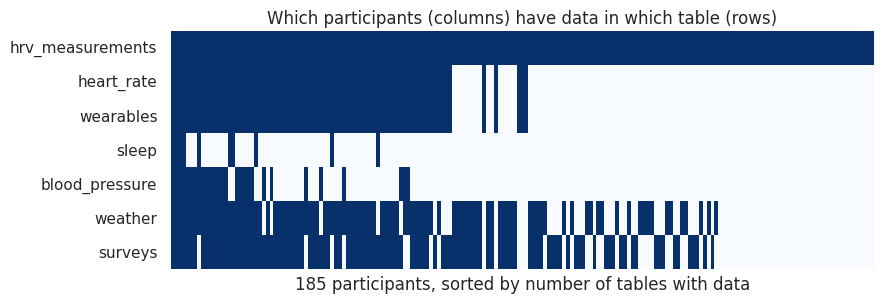

In [4]:
users = raw["participants"]["user_code"]
cov = pd.DataFrame({t: users.isin(raw[t]["user_code"]).values for t in TABLES if t not in ("participants", "scales_description")},
                   index=users.values)
print((cov.mean() * 100).round(1).sort_values(ascending=False).astype(str) + " %")

fig, ax = plt.subplots(figsize=(9, 3.2))
order = cov.sum(axis=1).sort_values(ascending=False).index
sns.heatmap(cov.loc[order].T.astype(int), cbar=False, cmap="Blues", ax=ax, xticklabels=False)
ax.set_title("Which participants (columns) have data in which table (rows)")
ax.set_xlabel("185 participants, sorted by number of tables with data")
plt.tight_layout(); plt.show()

**Interpretation.** HRV measurements exist for all 185 users, since that was the entry point to the study. Surveys cover about 60% and weather about 56%. Only about 43% of users (79) have wearable/heart-rate data, and very few have sleep (10) or blood pressure (28). So any analysis that joins wearables to HRV runs on a much smaller, more affluent, device-owning sub-population. Sleep and BP are too sparse for population-level conclusions.

## 3. Documentation vs. Reality — Schema & Unit Audit
Before trusting any number, I checked whether the values match what `datatypes.md` claims. Several do **not**, and that matters for any downstream interpretation or unit conversion.

In [5]:
h, w, sl = raw["hrv_measurements"], raw["wearables"], raw["sleep"]
audit = pd.DataFrame([
    ["hrv.mode", "milliseconds", f"median {h['mode'].median():.2f}", "seconds (mode×1000 ≈ meanrr)"],
    ["hrv.mxdmn", "seconds", f"median {h['mxdmn'].median():.2f}", "seconds ✔"],
    ["wearables.average_spo2_value", "%", f"median {w['average_spo2_value'].median():.2f}", "fraction 0–1"],
    ["sleep.sleep_duration", "hours", f"median {sl['sleep_duration'].median():,.0f}", "seconds (= sleep_end − sleep_begin)"],
    ["heart_rate.csv time column", "`daytime`", "column is `datetime`", "name mismatch"],
    ["blood_pressure.measurement_datetime", "YYYY-MM-DD hh:mm:ss", repr(raw['blood_pressure']['measurement_datetime'].iloc[0]), "double space between date & time"],
    ["participants.symptoms_onset", "MM/DD/YYYY", "different format from every other date column", "format inconsistency ✔ documented"],
    ["hrv.how_feel / how_mood / how_sleep", "(no scale given)", f"values {sorted(h['how_feel'].unique())}", "undocumented −2…+2 scale"],
    ["weather.atmospheric_pressure", "mmHg", f"median {raw['weather']['atmospheric_pressure'].median():.0f}", "hPa/mbar (≈1013 at sea level; mmHg would be ≈760)"],
], columns=["field", "documented as", "observed", "actual"])
audit

,field,documented as,observed,actual
0,hrv.mode,milliseconds,median 0.82,seconds (mode×1000 ≈ meanrr)
1,hrv.mxdmn,seconds,median 0.16,seconds ✔
2,wearables.average_spo2_value,%,median 0.96,fraction 0–1
3,sleep.sleep_duration,hours,"median 26,041",seconds (= sleep_end − sleep_begin)
4,heart_rate.csv time column,`daytime`,column is `datetime`,name mismatch
5,blood_pressure.measurement_datetime,YYYY-MM-DD hh:mm:ss,'2020-04-29 22:33:33',double space between date & time
6,participants.symptoms_onset,MM/DD/YYYY,different format from every other date column,format inconsistency ✔ documented
7,hrv.how_feel / how_mood / how_sleep,(no scale given),"values [np.int64(-2), np.int64(-1), np.int64(0...",undocumented −2…+2 scale
8,weather.atmospheric_pressure,mmHg,median 1014,hPa/mbar (≈1013 at sea level; mmHg would be ≈760)


**Rationale.** These discrepancies get fixed in the transformation step (§8), where all units are harmonized to what a reader would expect (ms, %, hours, hPa). Using the wrong units silently leads to errors such as a Baevsky Stress Index that is off by 1000×, or "7 hours of sleep" read as 25,000 hours.

## 4. Descriptive Statistics

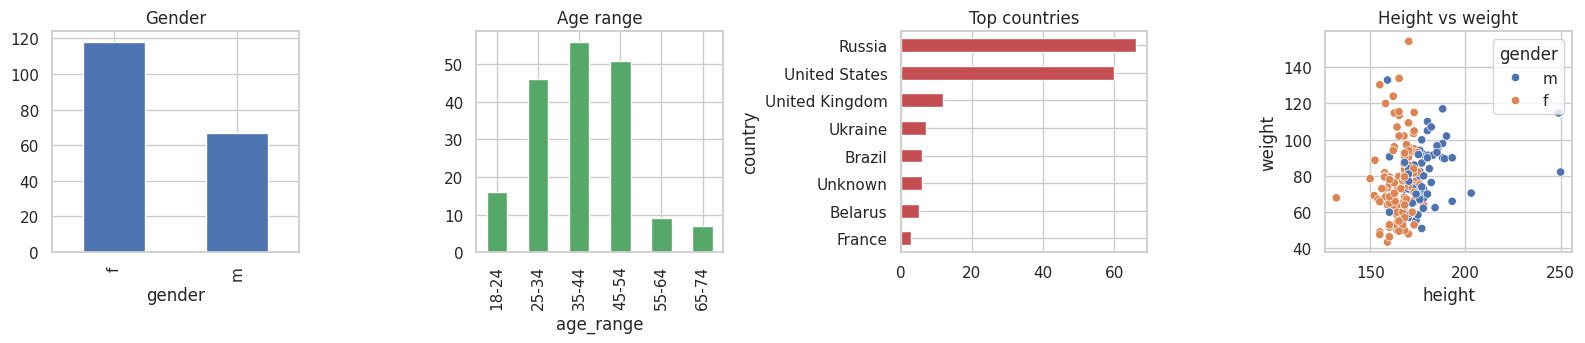

,count,mean,std,min,25%,50%,75%,max
height,183.0,169.976393,12.400103,132.08,163.5,168.000,174.500,250.000
weight,185.0,77.927757,19.552541,43.50,63.5,74.344,90.537,154.221


In [6]:
p = raw["participants"].copy()
fig, axes = plt.subplots(1, 4, figsize=(16, 3.6))
p["gender"].value_counts().plot.bar(ax=axes[0], color="#4C72B0", title="Gender")
p["age_range"].value_counts().sort_index().plot.bar(ax=axes[1], color="#55A868", title="Age range")
p["country"].fillna("Unknown").value_counts().head(8).plot.barh(ax=axes[2], color="#C44E52", title="Top countries")
axes[2].invert_yaxis()
sns.scatterplot(data=p, x="height", y="weight", hue="gender", ax=axes[3]); axes[3].set_title("Height vs weight")
plt.tight_layout(); plt.show()
p[["height", "weight"]].describe().T

In [7]:
hrv_num = ["bpm", "meanrr", "sdnn", "rmssd", "pnn50", "mode", "amo", "mxdmn", "lf", "hf", "vlf", "lfhf", "total_power"]
desc = h[hrv_num].describe().T
desc["skew"] = h[hrv_num].skew()
desc["cv"] = desc["std"] / desc["mean"]
desc.round(2)

,count,mean,std,min,25%,50%,75%,max,skew,cv
bpm,3245.0,73.26,12.20,44.00,65.00,72.00,81.00,125.00,0.48,0.17
meanrr,3245.0,839.60,137.42,477.73,742.49,829.10,925.93,1346.74,0.33,0.16
sdnn,3245.0,52.49,29.37,9.52,32.58,46.92,64.41,206.63,1.72,0.56
rmssd,3245.0,52.81,39.35,6.34,28.98,42.87,62.48,310.80,2.66,0.75
pnn50,3245.0,20.62,18.59,0.00,6.06,16.16,29.29,91.92,1.41,0.90
mode,3245.0,0.84,0.14,0.48,0.72,0.82,0.92,1.32,0.39,0.17
amo,3245.0,46.79,16.42,12.00,35.00,45.00,57.00,98.00,0.53,0.35
mxdmn,3245.0,0.18,0.11,0.03,0.11,0.16,0.22,0.79,1.69,0.58
lf,3245.0,927.04,1455.42,2.00,151.00,423.00,1059.00,15522.00,3.80,1.57
hf,3245.0,1125.04,2490.54,4.00,158.00,380.00,993.00,33490.00,5.34,2.21


**Interpretation.**
- Heart-rate-type metrics (`bpm`, `meanrr`, `mode`) are roughly symmetric and tightly bounded (44–125 bpm, all physiologically plausible).
- Variability metrics are **right-skewed** (RMSSD skew above 2).
- Spectral powers (`lf`, `hf`, `vlf`, `total_power`, `lfhf`) are **extremely skewed**, with coefficients of variation above 1.5 and maxima 10–40× the median. That is typical of HRV power data, which is approximately log-normal, so a **log transform** is the standard treatment rather than outlier deletion.
- Self-report scores cluster at 0, with a negative lean (`how_feel` mean −0.24). That is plausible for sick participants.

In [8]:
print("how_feel / how_mood / how_sleep value counts (NaN included):")
pd.concat({c: h[c].value_counts(dropna=False).sort_index() for c in ["how_feel", "how_mood", "how_sleep"]}, axis=1)

how_feel / how_mood / how_sleep value counts (NaN included):


,how_feel,how_mood,how_sleep
-2.0,124.0,96.0,50
-1.0,857.0,471.0,238
0.0,1975.0,2335.0,967
1.0,237.0,272.0,180
2.0,52.0,71.0,31
NaN,NaN,NaN,1779


In [9]:
wear_num = w.select_dtypes("number").columns
wd = w[wear_num].describe().T
wd["pct_missing"] = w[wear_num].isna().mean() * 100
wd.round(1).sort_values("pct_missing")

,count,mean,std,min,25%,50%,75%,max,pct_missing
basal_calories_burned,3097.0,2258.2,341.5,81.0,1968.0,2271.0,2569.0,3395.0,0.0
total_calories_burned,3097.0,2549.0,804.6,81.0,2001.0,2353.0,2668.0,8418.0,0.0
pulse_average,2089.0,78.1,14.4,48.0,69.0,76.0,85.0,163.0,32.6
pulse_min,2089.0,63.1,14.3,10.0,53.0,60.0,72.0,122.0,32.6
pulse_max,2089.0,99.5,29.3,48.0,76.0,96.0,118.0,225.0,32.6
steps_count,1968.0,5342.1,4761.8,1.0,1456.0,4477.5,7857.2,30882.0,36.5
distance,1869.0,3494.7,3599.6,1.0,772.0,2687.0,5035.0,43914.0,39.7
resting_pulse,1515.0,61.4,12.8,40.0,52.0,58.0,69.0,109.0,51.1
steps_speed,1418.0,29.7,28.1,0.0,10.4,24.6,44.1,240.0,54.2
total_number_of_flights_climbed,1235.0,16.2,20.8,1.0,3.0,9.0,22.0,164.0,60.1


In [10]:
print("Heart rate samples:"); print(raw["heart_rate"]["heart_rate"].describe().round(1).to_string())
print("\nBlood pressure:"); print(raw["blood_pressure"][["systolic", "diastolic"]].describe().round(1).to_string())
print("\nSurvey scales (top 12 by volume):"); print(raw["surveys"]["scale"].value_counts().head(12).to_string())

Heart rate samples:
count    523783.0
mean         90.9
std          25.1
min          10.0
25%          71.0
50%          87.0
75%         108.0
max         232.0

Blood pressure:
       systolic  diastolic
count     721.0      721.0
mean      119.4       81.2
std        10.5        8.9
min        63.0       25.0
25%       113.0       76.0
50%       120.0       82.0
75%       126.0       88.0
max       157.0      101.0

Survey scales (top 12 by volume):
scale
S_COVID_FATIGUE      209
S_COVID_COUGH        207
S_COVID_OVERALL      207
S_COVID_TROUBLE      206
S_COVID_BREATH       205
S_COVID_CONFUSION    204
S_COVID_PAIN         204
S_COVID_BLUISH       203
S_COVID_FEVER        203
S_CORONA              86
S_HRA_ALC             51
S_HRA_VIT             41


## 5. Data Quality Profiling
### 5.1 Completeness

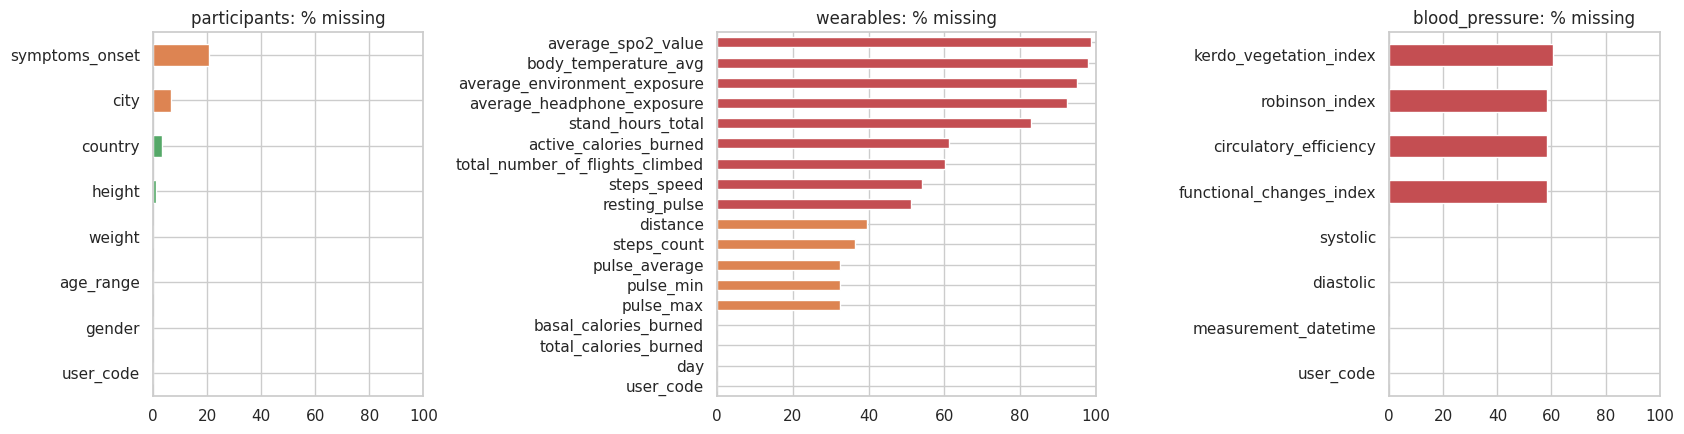

hrv_measurements missing %: {'how_sleep': 54.8, 'tags': 32.2}
sleep missing %: {'sleep_awake_duration': 97.9, 'sleep_rem_duration': 98.4, 'sleep_light_duration': 93.6, 'sleep_deep_duration': 96.7, 'pulse_min': 96.5, 'pulse_max': 96.5, 'pulse_average': 96.5}


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5), gridspec_kw={"width_ratios": [1, 1.4, 1]})
for ax, t in zip(axes, ["participants", "wearables", "blood_pressure"]):
    m = raw[t].isna().mean().mul(100).sort_values()
    m.plot.barh(ax=ax, color=np.where(m > 50, "#C44E52", np.where(m > 5, "#DD8452", "#55A868")))
    ax.set_title(f"{t}: % missing"); ax.set_xlim(0, 100)
plt.tight_layout(); plt.show()

print("hrv_measurements missing %:", h.isna().mean().mul(100).round(1)[lambda s: s > 0].to_dict())
print("sleep missing %:", sl.isna().mean().mul(100).round(1)[lambda s: s > 0].to_dict())

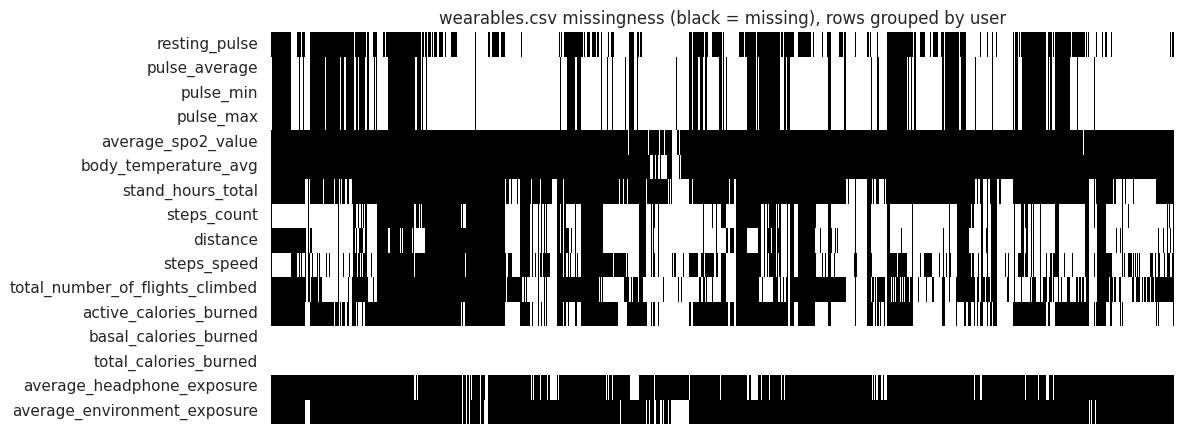

% of wearable users who NEVER report the column:
 pulse_average                       0.0
pulse_min                           0.0
pulse_max                           0.0
total_calories_burned               0.0
basal_calories_burned               0.0
resting_pulse                      29.0
steps_count                        58.0
distance                           58.0
steps_speed                        59.0
active_calories_burned             67.0
total_number_of_flights_climbed    68.0
stand_hours_total                  81.0
average_headphone_exposure         84.0
average_environment_exposure       94.0
average_spo2_value                 96.0
body_temperature_avg               99.0


In [12]:
# Missingness *pattern* in wearables: is missingness random, or does it follow device capability?
fig, ax = plt.subplots(figsize=(12, 4.5))
ws = w.sort_values(["user_code", "day"])
sns.heatmap(ws[wear_num].isna().T, cbar=False, cmap="Greys", ax=ax, xticklabels=False)
ax.set_title("wearables.csv missingness (black = missing), rows grouped by user")
plt.tight_layout(); plt.show()

# Per-user: share of users for which a column is *entirely* missing
per_user_all_missing = ws.groupby("user_code")[wear_num].apply(lambda g: g.isna().all()).mean().mul(100)
print("% of wearable users who NEVER report the column:\n", per_user_all_missing.round(0).sort_values().to_string())

**Interpretation.** The missingness shows up as **vertical blocks per user**, not scattered noise. For example, SpO₂ and body temperature are almost never present because only a few devices measure them, and `stand_hours_total` is an Apple Watch concept. That makes it **Missing Not At Random (MNAR) / structural**: whether a value exists depends on the user's device. Statistical imputation (mean, KNN) would invent measurements that the device could never have produced, so I avoid it for these fields (§7.3).

In `hrv_measurements`, `how_sleep` is missing in 55% of rows. It is plausibly asked only for morning measurements, which I test below. `tags` is missing in 32% of rows, meaning the user simply didn't tag.

In [13]:
pd.crosstab(h["time_of_day"], h["how_sleep"].isna(), normalize="index").rename(columns={False: "answered", True: "missing"}).mul(100).round(1)

how_sleep,answered,missing
time_of_day,,
day,3.1,96.9
evening,0.0,100.0
morning,98.2,1.8
night,0.4,99.6


Confirmed: `how_sleep` is answered for about 98% of morning measurements and almost never otherwise. It is **missing by design** (the question isn't asked), not missing at random, so it should stay NaN rather than be imputed.

### 5.2 Uniqueness / duplicates

In [14]:
keys = {
    "participants": ["user_code"],
    "hrv_measurements": ["rr_code"],
    "heart_rate": ["user_code", "datetime"],
    "wearables": ["user_code", "day"],
    "sleep": ["user_code", "day"],
    "blood_pressure": ["user_code", "measurement_datetime"],
    "weather": ["user_code", "day"],
    "surveys": ["user_code", "scale", "created_at"],
}
dup = pd.DataFrame([{
    "table": t, "natural_key": " + ".join(k),
    "exact_duplicate_rows": raw[t].duplicated().sum(),
    "duplicate_keys": raw[t].duplicated(k).sum(),
} for t, k in keys.items()]).set_index("table")
dup

,natural_key,exact_duplicate_rows,duplicate_keys
table,,,
participants,user_code,0,0
hrv_measurements,rr_code,0,0
heart_rate,user_code + datetime,0,7330
wearables,user_code + day,0,0
sleep,user_code + day,0,38
blood_pressure,user_code + measurement_datetime,0,0
weather,user_code + day,0,0
surveys,user_code + scale + created_at,0,24


In [15]:
hr_raw = raw["heart_rate"]
d = hr_raw[hr_raw.duplicated(["user_code", "datetime"], keep=False)]
spread = d.groupby(["user_code", "datetime"])["heart_rate"].agg(lambda s: s.max() - s.min())
print("Heart-rate key duplicates: value spread (bpm) between conflicting rows")
print(spread.describe().round(2).to_string())
sd_ = sl[sl.duplicated(["user_code", "day"], keep=False)].assign(b=lambda d: pd.to_datetime(d["sleep_begin"]))
tz_check = sd_.groupby(["user_code", "day"]).agg(same_duration=("sleep_duration", lambda x: x.nunique() == 1),
                                                   start_shift=("b", lambda x: x.max() - x.min()))
print("\nSleep duplicate days: identical duration in", f"{tz_check['same_duration'].mean():.0%}", "of cases; start-time shifts:")
print(tz_check["start_shift"].value_counts().to_string())
print(sl[sl.duplicated(["user_code", "day"], keep=False)].head(4).to_string())

Heart-rate key duplicates: value spread (bpm) between conflicting rows
count    7256.00
mean        9.34
std        11.68
min         0.00
25%         1.00
50%         4.00
75%        15.00
max       121.00

Sleep duplicate days: identical duration in 100% of cases; start-time shifts:
start_shift
0 days 03:00:00    16
0 days 01:00:00    15
0 days 02:00:00     2
0 days 04:00:00     1
0 days 05:00:00     1
0 days 02:30:00     1
      user_code         day          sleep_begin            sleep_end  sleep_duration  sleep_awake_duration  sleep_rem_duration  sleep_light_duration  sleep_deep_duration  pulse_min  pulse_max  pulse_average
202  4985083f4d  2020-03-10  2020-03-09 23:18:09  2020-03-10 07:20:06         28917.0                   NaN                 NaN                   NaN                  NaN        NaN        NaN            NaN
203  4985083f4d  2020-03-10  2020-03-09 21:18:09  2020-03-10 05:20:06         28917.0                   NaN                 NaN                   NaN     

**Interpretation.** No row is an *exact* duplicate, but three tables have **duplicate natural keys**:
- **heart_rate:** 7,330 timestamps appear twice with *different* values. The median gap is 4 bpm, but the tail reaches over 100 bpm. That pattern is consistent with two sources (e.g., watch + phone, or a manual entry) writing to Apple Health / Google Fit at the same second. They are conflicting readings of one moment, not independent observations.
- **sleep:** 38 extra rows. At first glance these look like naps, but the check below shows every "duplicate" has an **identical duration** and a start time shifted by **exactly 1–5 whole hours**. That is the same night stored twice under different **time-zone offsets**.
- **surveys:** 24 repeated answers of the same scale on the same day.

### 5.3 Validity (domain & plausibility rules)

In [16]:
bp = raw["blood_pressure"]
onset = pd.to_datetime(p["symptoms_onset"], format="%m/%d/%Y", errors="coerce")
STUDY_START, STUDY_END = pd.Timestamp("2019-11-01"), pd.Timestamp("2020-06-30")
rules = [
    ("participants", "symptoms_onset outside Nov-2019…Jun-2020", ((onset < STUDY_START) | (onset > STUDY_END)).sum()),
    ("participants", "height outside 140–220 cm", (~p["height"].between(140, 220) & p["height"].notna()).sum()),
    ("participants", "BMI < 15 or > 60", (~(p["weight"] / (p["height"] / 100) ** 2).between(15, 60) & p["height"].notna()).sum()),
    ("heart_rate", "heart_rate < 30 or > 220 bpm", (~hr_raw["heart_rate"].between(30, 220)).sum()),
    ("wearables", "pulse_min < 30 bpm", (w["pulse_min"] < 30).sum()),
    ("wearables", "pulse_max < pulse_average", (w["pulse_max"] < w["pulse_average"]).sum()),
    ("wearables", "steps_speed > 200 steps/min", (w["steps_speed"] > 200).sum()),
    ("wearables", "total_calories < 1000 kcal/day", (w["total_calories_burned"] < 1000).sum()),
    ("blood_pressure", "diastolic < 40 mmHg", (bp["diastolic"] < 40).sum()),
    ("blood_pressure", "systolic <= diastolic", (bp["systolic"] <= bp["diastolic"]).sum()),
    ("sleep", "sleep_duration < 1 h or > 13 h", (~(sl["sleep_duration"] / 3600).between(1, 13)).sum()),
    ("hrv", "RR recording < 60 s", (h["rr_data"].str.split(",").apply(lambda x: sum(map(float, x))) < 60000).sum()),
]
validity = pd.DataFrame(rules, columns=["table", "rule", "violations"])
validity

,table,rule,violations
0,participants,symptoms_onset outside Nov-2019…Jun-2020,13
1,participants,height outside 140–220 cm,3
2,participants,BMI < 15 or > 60,1
3,heart_rate,heart_rate < 30 or > 220 bpm,114
4,wearables,pulse_min < 30 bpm,6
5,wearables,pulse_max < pulse_average,1
6,wearables,steps_speed > 200 steps/min,6
7,wearables,total_calories < 1000 kcal/day,1
8,blood_pressure,diastolic < 40 mmHg,1
9,blood_pressure,systolic <= diastolic,0


In [17]:
print("Invalid onset dates:\n", p.loc[(onset < STUDY_START) | (onset > STUDY_END), ["user_code", "symptoms_onset", "height"]].to_string())

Invalid onset dates:
       user_code symptoms_onset  height
20   1942df1c47       3/6/1999  165.10
24   1f2eb6aded       7/7/1987  159.00
29   262f55c029     11/26/1981  165.10
45   393bac62f4      4/21/2022  172.72
49   3fff7627ca       4/5/1984  248.92
62   50249775be     12/16/1982  181.00
79   638c757e73       4/1/2021  168.00
91   78cc008261      1/30/1967  176.00
94   7badc26d11      8/15/1968  187.96
102  83161408c1       1/1/1993  250.00
123  a46379283f      3/28/1975  160.00
127  a78719c4a1     11/20/1977  160.02
136  b3c7f65a4b       6/7/2000  193.00


**Interpretation.**
- **13 onset dates (7% of participants) are impossible** for a 2020 study. Ten fall between 1967 and 2000 and look like **birth dates typed into the wrong field**; the rest are 2021/2022. This is a UI/label-quality problem, not random noise.
- The two users with **~250 cm** heights *also* have invalid onset dates, which suggests careless form entry. That makes their other self-reported fields less trustworthy, so they are flagged at the user level rather than only in the offending cells.
- A 25 mmHg diastolic reading and a 10 bpm wearable pulse are almost certainly sensor or entry errors. The 114 heart-rate samples outside 30–220 bpm are too.
- **99 HRV recordings are shorter than 60 s.** They aren't invalid, but short recordings make LF and especially VLF power unreliable (standard guidance calls for ≥ 2 min for LF and ≥ 5 min for VLF). I keep them and expose `rec_duration_s` (§9) so analyses can filter on it.
- Sub-1000-kcal "total calorie" days are most likely **partial-day syncs** rather than real values, which is a completeness problem disguised as a valid number.

### 5.4 Consistency & accuracy checks (cross-field and cross-source)
The raw `rr_data` column holds the underlying beat intervals. That lets me **recompute** the derived metrics independently and test whether the published numbers are accurate, which is rarely possible with an app export.

In [18]:
rr = h["rr_data"].str.split(",").apply(lambda x: np.asarray(x, dtype=float))
recomputed = pd.DataFrame({
    "meanrr": rr.apply(np.mean),
    "sdnn": rr.apply(lambda a: np.std(a, ddof=1)),
    "rmssd": rr.apply(lambda a: np.sqrt(np.mean(np.diff(a) ** 2))),
    "pnn50": rr.apply(lambda a: np.mean(np.abs(np.diff(a)) > 50) * 100),
})
checks = pd.DataFrame({
    col: {"max_abs_diff": (recomputed[col] - h[col]).abs().max(),
          "pearson_r": np.corrcoef(recomputed[col], h[col])[0, 1]}
    for col in recomputed
}).T
checks.loc["bpm vs 60000/meanrr"] = [(h["bpm"] - 60000 / h["meanrr"]).abs().max(), np.corrcoef(h["bpm"], 60000 / h["meanrr"])[0, 1]]
checks.loc["total_power vs lf+hf+vlf"] = [(h["lf"] + h["hf"] + h["vlf"] - h["total_power"]).abs().max(), 1.0]
checks.loc["lfhf vs lf/hf"] = [(h["lf"] / h["hf"] - h["lfhf"]).abs().max(), np.corrcoef(h["lf"] / h["hf"], h["lfhf"])[0, 1]]
checks.round(3)

,max_abs_diff,pearson_r
meanrr,0.000,1.000
sdnn,0.000,1.000
rmssd,0.000,1.000
pnn50,0.005,1.000
bpm vs 60000/meanrr,3.472,0.999
total_power vs lf+hf+vlf,0.000,1.000
lfhf vs lf/hf,0.001,1.000


wearables: total == basal + active   -> True
wearables: when active is missing, total == basal -> 99.95 % of rows
sleep: sleep_duration == end − begin -> True
hrv: time_of_day inconsistent with timestamp hour -> 14 rows (0.4%)


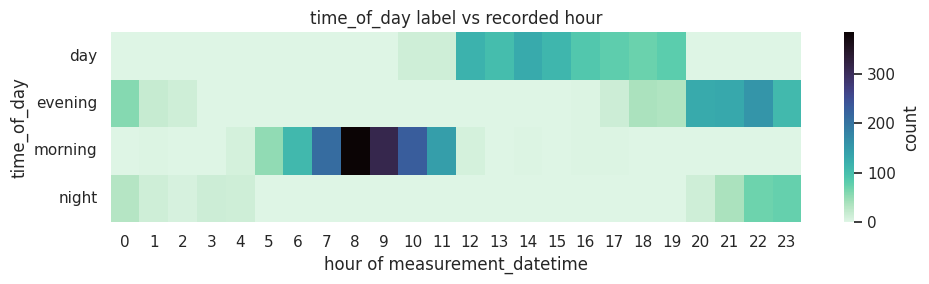

In [19]:
wa = w[w["active_calories_burned"].notna()]
print("wearables: total == basal + active   ->", np.allclose(wa["total_calories_burned"], wa["basal_calories_burned"] + wa["active_calories_burned"]))
wn = w[w["active_calories_burned"].isna()]
print("wearables: when active is missing, total == basal ->", round((wn["total_calories_burned"] == wn["basal_calories_burned"]).mean() * 100, 2), "% of rows")
dur = (pd.to_datetime(sl["sleep_end"]) - pd.to_datetime(sl["sleep_begin"])).dt.total_seconds()
print("sleep: sleep_duration == end − begin ->", np.allclose(dur, sl["sleep_duration"]))

# time_of_day label vs. timestamp hour
hour = pd.to_datetime(h["measurement_datetime"]).dt.hour
windows = {"morning": set(range(3, 14)), "day": set(range(9, 22)),
           "evening": set(range(14, 24)) | {0, 1, 2, 3}, "night": set(range(19, 24)) | set(range(0, 6))}
tod_bad = ~pd.Series([hr_ in windows[t] for hr_, t in zip(hour, h["time_of_day"])], index=h.index)
print(f"hrv: time_of_day inconsistent with timestamp hour -> {tod_bad.sum()} rows ({tod_bad.mean():.1%})")
fig, ax = plt.subplots(figsize=(10, 3))
sns.heatmap(pd.crosstab(h["time_of_day"], hour), cmap="mako_r", ax=ax, cbar_kws={"label": "count"})
ax.set_xlabel("hour of measurement_datetime"); ax.set_title("time_of_day label vs recorded hour")
plt.tight_layout(); plt.show()

**Interpretation.**
- **Derived HRV metrics are internally accurate.** Recomputing them from `rr_data` reproduces the stored values almost exactly (r ≈ 1), and the spectral identities hold. Caveat: this proves *computational* consistency, not *physiological* accuracy. If camera PPG mis-detected beats, the RR intervals themselves are wrong, and every derived metric inherits the error. §9 adds an artifact-rate feature to help catch that.
- **`bpm` differs from 60000/meanrr by up to about 3.5 bpm.** That is rounding plus probably a different averaging window, so it's acceptable.
- **Calories reveal a hidden encoding.** When `active_calories_burned` is missing, `total == basal`. The source system treated missing active calories as **0**, which tells me how to handle that column.
- **`time_of_day` is mostly consistent with the timestamp hour**, which suggests timestamps are in local time. The small inconsistent share could come from user-chosen labels or time-zone shifts. Time-zone information is **not provided**, a lineage gap.

### 5.5 Referential integrity

In [20]:
known = set(p["user_code"])
ri = pd.DataFrame([{"table": t, "rows": len(raw[t]),
                    "orphan_user_codes": len(set(raw[t]["user_code"]) - known),
                    "orphan_rows": (~raw[t]["user_code"].isin(known)).sum()}
                   for t in keys if t != "participants"]).set_index("table")
codes_in_surveys = set(raw["surveys"]["scale"]); codes_in_book = set(raw["scales_description"]["Scale"])
print("Survey scales missing from code book:", sorted(codes_in_surveys - codes_in_book))
print("user_code format all 10-char hex:", all(pd.concat([raw[t]['user_code'] for t in keys]).str.fullmatch(r"[0-9a-f]{10}")))
ri

Survey scales missing from code book: []
user_code format all 10-char hex: True


,rows,orphan_user_codes,orphan_rows
table,,,
hrv_measurements,3245,0,0
heart_rate,523783,0,0
wearables,3098,0,0
sleep,425,0,0
blood_pressure,721,0,0
weather,1717,0,0
surveys,2259,0,0


In [21]:
sd = raw["scales_description"]
print("Malformed code-book rows (embedded newlines broke the CSV quoting):")
sd[sd["Scale"].str.contains("\n", na=False) | sd["Description"].isna() | sd["Value"].isna()].head()

Malformed code-book rows (embedded newlines broke the CSV quoting):


,Scale,Description,Value,Meaning
77,S_HRA_MONTH\n,How far along in their pregnancy the user is,1,User is less than 3 months pregnant when takin...
78,S_HRA_MONTH\n,How far along in their pregnancy the user is,2,User is less than 3-4 months pregnant when tak...
79,S_HRA_MONTH\n,How far along in their pregnancy the user is,3,User is less than 5-6 months pregnant when tak...
80,S_HRA_MONTH\n,How far along in their pregnancy the user is,4,User is more than 7 months pregnant when takin...


**Interpretation.** Referential integrity on `user_code` is perfect: no orphan rows, and IDs are consistently formatted. The **code book itself is malformed**, though. A few rows contain embedded newlines, so scale names like `S_HRA_MONTH` and `S_HRA_HEART` are garbled when parsed. Any scale-to-meaning lookup needs to be defensive.

## 6. Visual Exploration & Variable Relationships
### 6.1 Engagement is extremely uneven

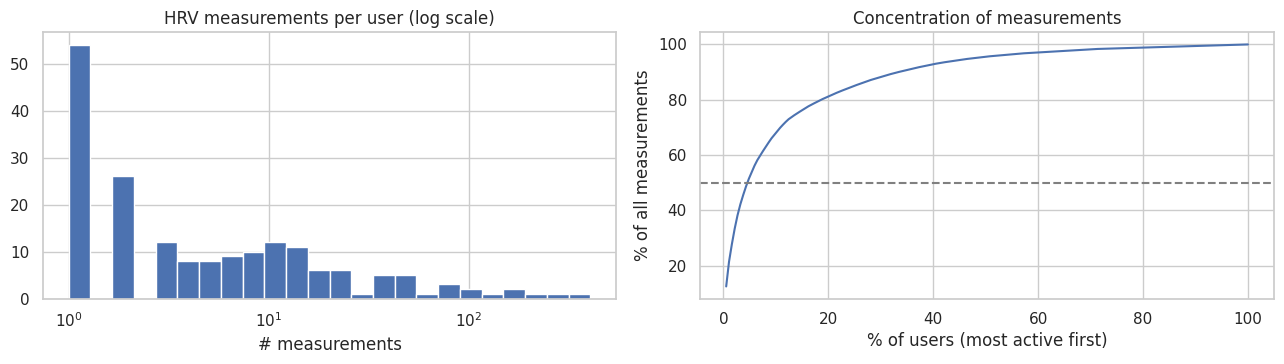

Top 10 users contribute 54% of all HRV rows; 54 users measured only once.


In [22]:
per_user = h.groupby("user_code").size().sort_values(ascending=False)
fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
axes[0].hist(per_user, bins=np.logspace(0, np.log10(per_user.max() + 1), 25), color="#4C72B0")
axes[0].set_xscale("log"); axes[0].set_title("HRV measurements per user (log scale)"); axes[0].set_xlabel("# measurements")
cum = per_user.cumsum() / per_user.sum()
axes[1].plot(np.arange(1, len(cum) + 1) / len(cum) * 100, cum.values * 100)
axes[1].axhline(50, ls="--", c="grey"); axes[1].set_xlabel("% of users (most active first)"); axes[1].set_ylabel("% of all measurements")
axes[1].set_title("Concentration of measurements")
plt.tight_layout(); plt.show()
print(f"Top 10 users contribute {per_user.head(10).sum() / len(h):.0%} of all HRV rows; {int((per_user == 1).sum())} users measured only once.")

**Implication.** Pooled row-level statistics are dominated by a handful of people. For population-level claims I'll prefer **per-user aggregation** or **per-user normalization**, and any train/test split should be **grouped by user** to avoid leakage.

### 6.2 Distributions — raw vs. log

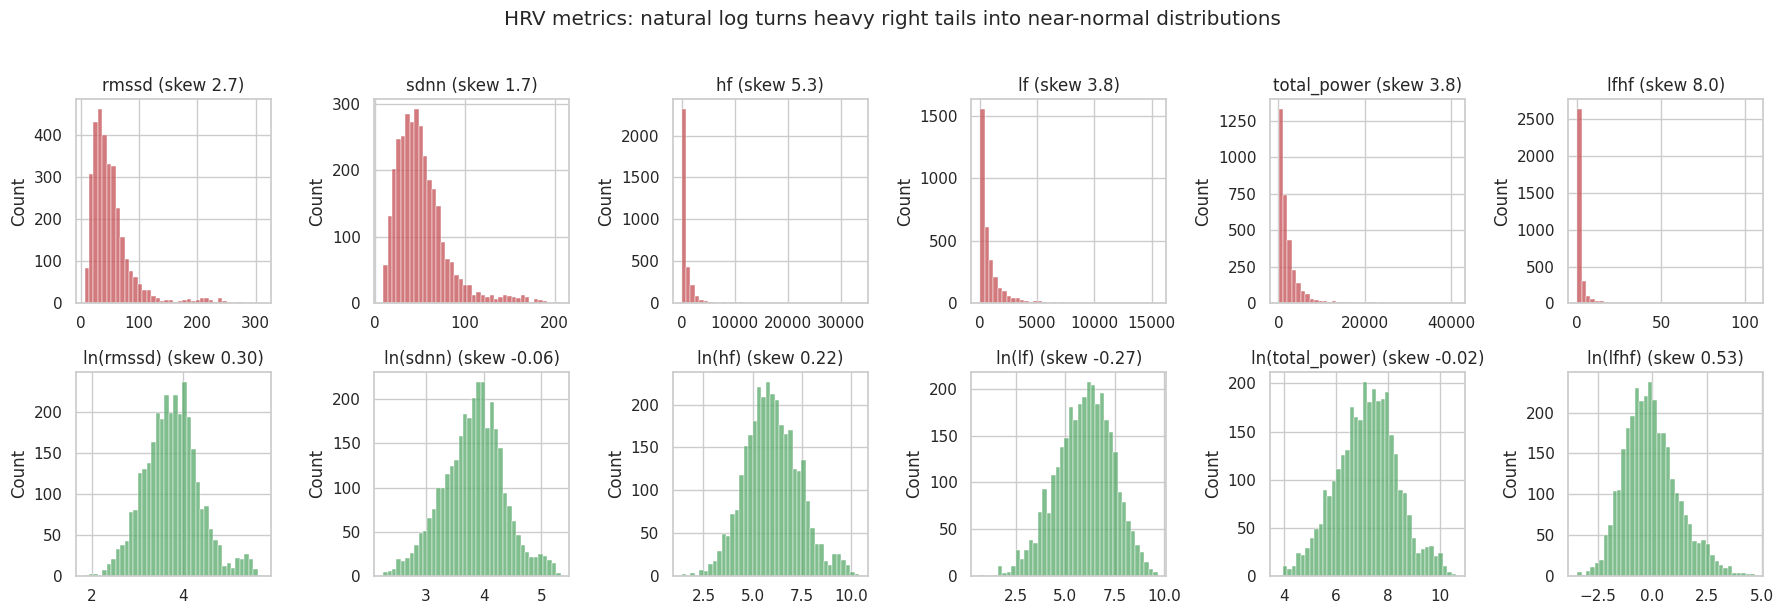

In [23]:
cols = ["rmssd", "sdnn", "hf", "lf", "total_power", "lfhf"]
fig, axes = plt.subplots(2, len(cols), figsize=(18, 6))
for i, c in enumerate(cols):
    sns.histplot(h[c], ax=axes[0, i], bins=40, color="#C44E52"); axes[0, i].set_title(f"{c} (skew {h[c].skew():.1f})")
    sns.histplot(np.log(h[c]), ax=axes[1, i], bins=40, color="#55A868"); axes[1, i].set_title(f"ln({c}) (skew {np.log(h[c]).skew():.2f})")
    axes[0, i].set_xlabel(""); axes[1, i].set_xlabel("")
plt.suptitle("HRV metrics: natural log turns heavy right tails into near-normal distributions", y=1.02)
plt.tight_layout(); plt.show()

The log transform brings skew from roughly 2–12 down to near 0, which confirms approximate log-normality. That is the basis for using log scale in outlier detection and modeling (§7.4, §8).

### 6.3 Correlations among HRV metrics

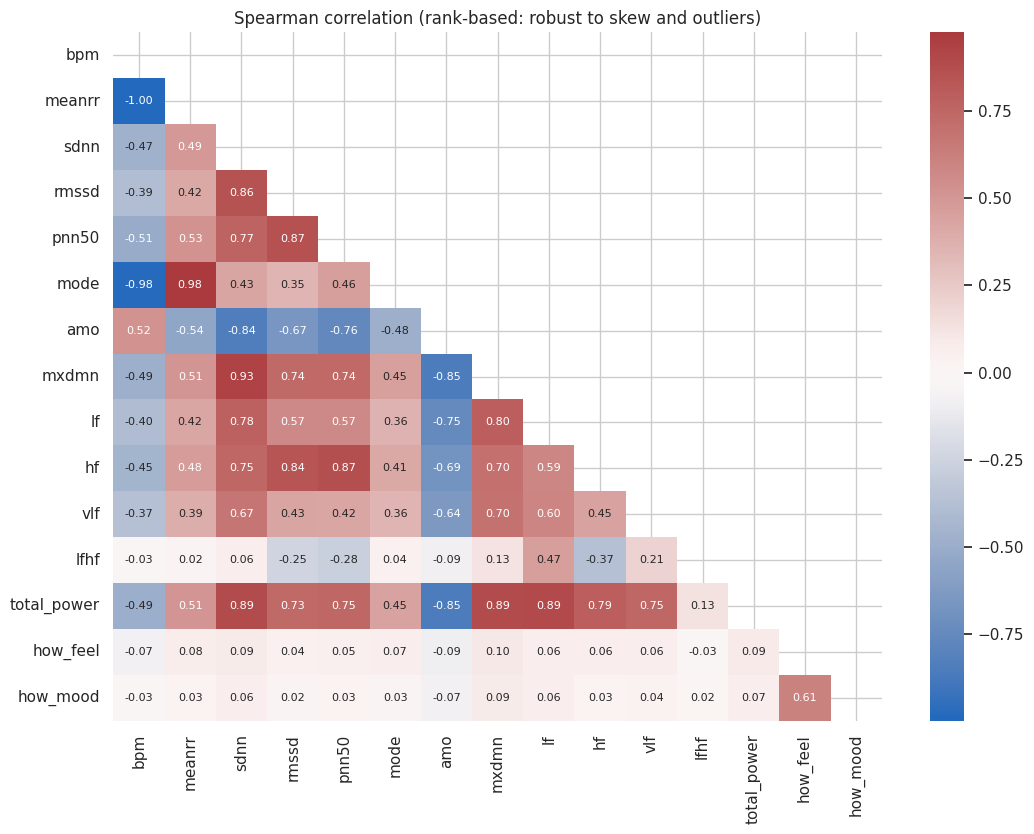

In [24]:
corr = h[hrv_num + ["how_feel", "how_mood"]].corr(method="spearman")
fig, ax = plt.subplots(figsize=(11, 8.5))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="vlag", center=0, ax=ax, annot_kws={"size": 8})
ax.set_title("Spearman correlation (rank-based: robust to skew and outliers)")
plt.tight_layout(); plt.show()

**Interpretation.**
- **Heavy redundancy.** `bpm`↔`meanrr`↔`mode` are near-perfectly (inversely) correlated because they are the same quantity. `rmssd`↔`pnn50`↔`hf` and `sdnn`↔`total_power`↔`mxdmn` form tight clusters, and `amo` is strongly negative with variability.
- **Feature selection implication.** For modeling, one representative per cluster (e.g., `bpm`, `ln_rmssd`, `ln_lf`/`lfhf`) avoids multicollinearity with little information loss.
- **Heart rate vs. variability.** Heart rate is moderately negatively related to variability: faster hearts have less time between beats to vary.
- **Self-report vs. physiology.** Correlations between `how_feel`/`how_mood` and HRV are weak but positive. Pooled across users, between-person baseline differences blur within-person effects, which is another reason for per-user normalization.

Spearman was chosen over Pearson because of the extreme skew and outliers shown in 6.2.

### 6.4 HRV by context: time of day and self-reported wellbeing

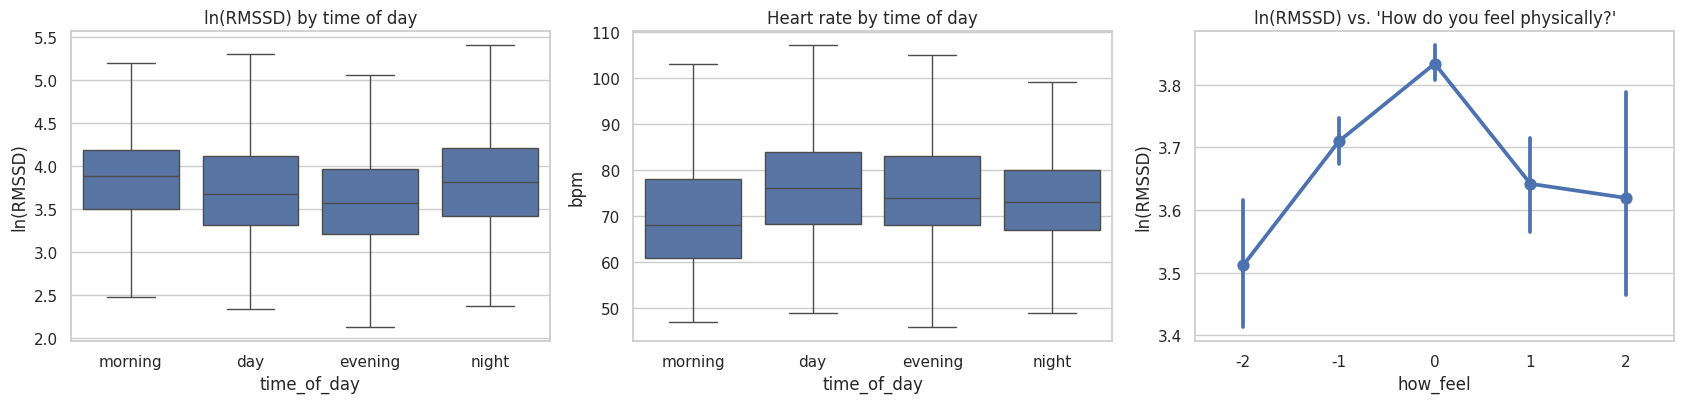

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.2))
order = ["morning", "day", "evening", "night"]
sns.boxplot(data=h, x="time_of_day", y=np.log(h["rmssd"]), order=order, ax=axes[0], showfliers=False)
axes[0].set_ylabel("ln(RMSSD)"); axes[0].set_title("ln(RMSSD) by time of day")
sns.boxplot(data=h, x="time_of_day", y="bpm", order=order, ax=axes[1], showfliers=False); axes[1].set_title("Heart rate by time of day")
sns.pointplot(data=h, x="how_feel", y=np.log(h["rmssd"]), ax=axes[2], errorbar=("ci", 95))
axes[2].set_ylabel("ln(RMSSD)"); axes[2].set_title("ln(RMSSD) vs. 'How do you feel physically?'")
plt.tight_layout(); plt.show()

**Interpretation.**
- **Time of day.** Morning measurements show higher HRV and lower heart rate, consistent with the known circadian pattern (vagal tone is higher after sleep). Time of day is therefore a **confounder**: comparing a morning reading with an evening reading conflates circadian and illness effects. Any before/after-COVID comparison should control for it or stratify by it.
- **Self-reported feel.** There is a monotonic trend where feeling worse goes with lower ln(RMSSD). It is modest, but it is the direction the physiology predicts.

### 6.5 Tags: what context do users record?

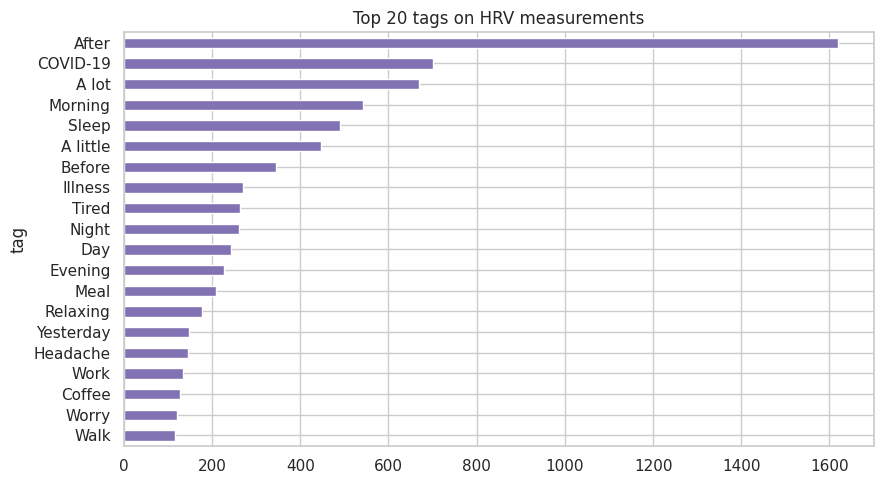

distinct tags: 61


In [26]:
tag_long = (h[["rr_code", "tags"]].dropna()
            .assign(tag=lambda d: d["tags"].str.split(";")).explode("tag")
            .assign(tag=lambda d: d["tag"].str.strip()).query("tag != ''"))
top_tags = tag_long["tag"].value_counts().head(20)
fig, ax = plt.subplots(figsize=(9, 5))
top_tags.sort_values().plot.barh(ax=ax, color="#8172B3"); ax.set_title("Top 20 tags on HRV measurements")
plt.tight_layout(); plt.show()
print("distinct tags:", tag_long["tag"].nunique())

Tags are a low-quality but information-rich signal. Many are **modifiers without their object** ("After", "A lot", "Before"), because the multi-select UI flattened phrases like "After *workout*". Some rows even carry nearly every tag (see the first raw row, which looks like "select all"). I'll use a small set of unambiguous tags ("COVID-19", "Illness", "Tired", "Coffee", "Alcohol", "Headache") as binary features and treat the rest cautiously.

### 6.6 Physiology around symptom onset (within-person view)

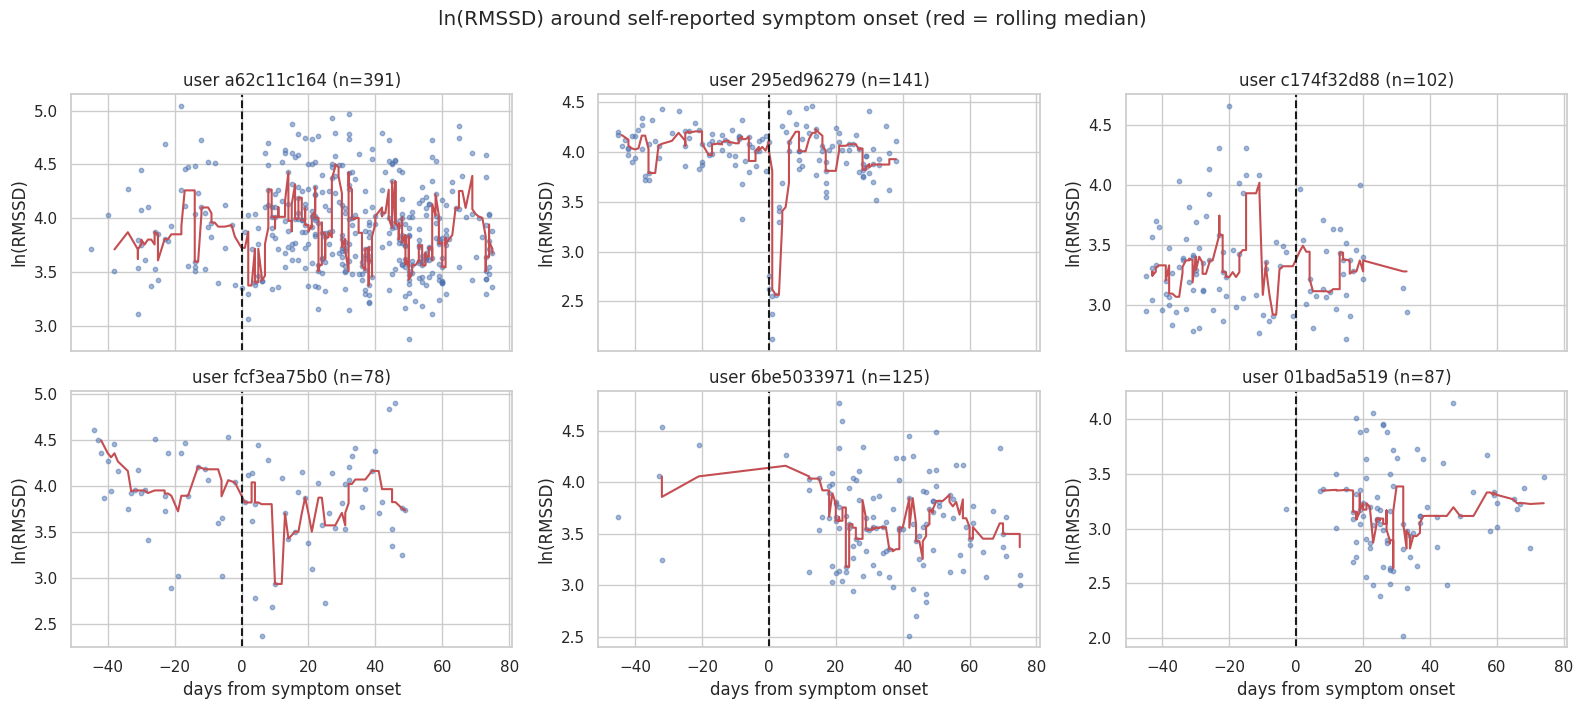

In [27]:
onset_clean = onset.where((onset >= STUDY_START) & (onset <= STUDY_END))
hv = h.merge(p[["user_code"]].assign(onset=onset_clean), on="user_code")
hv["days_from_onset"] = (pd.to_datetime(hv["measurement_datetime"]).dt.normalize() - hv["onset"]).dt.days
eligible = (hv.dropna(subset=["days_from_onset"]).groupby("user_code")["days_from_onset"]
            .agg(n="size", pre=lambda s: (s < 0).sum()).query("n >= 25 and pre >= 3").sort_values("n", ascending=False))
show = eligible.index[:6]
fig, axes = plt.subplots(2, 3, figsize=(16, 7), sharex=True)
for ax, u in zip(axes.flat, show):
    d = hv[(hv.user_code == u) & hv.days_from_onset.between(-45, 75)].sort_values("days_from_onset")
    ax.scatter(d["days_from_onset"], np.log(d["rmssd"]), s=10, alpha=.5)
    ax.plot(d["days_from_onset"], np.log(d["rmssd"]).rolling(7, min_periods=3).median(), c="C3")
    ax.axvline(0, c="k", ls="--"); ax.set_title(f"user {u} (n={len(d)})"); ax.set_ylabel("ln(RMSSD)")
for ax in axes[1]: ax.set_xlabel("days from symptom onset")
plt.suptitle("ln(RMSSD) around self-reported symptom onset (red = rolling median)", y=1.01)
plt.tight_layout(); plt.show()

**Interpretation.** Individual baselines differ a lot: one person's "low" is another's "high". Several users show a dip in HRV around or after onset followed by gradual recovery, but patterns are heterogeneous and noisy. This is the strongest argument for **personal-baseline features** (§9) rather than absolute thresholds.

## 7. Cleaning
All cleaning operates on copies (`clean[...]`), and every change is recorded in a `cleaning_log` for lineage.

In [28]:
clean = {t: d.copy() for t, d in raw.items()}
cleaning_log = []
def log(table, step, n, rationale):
    cleaning_log.append({"table": table, "step": step, "rows_affected": int(n), "rationale": rationale})

### 7.1 Removing duplicates
| Table | Strategy | Rationale |
|---|---|---|
| all | drop exact duplicate rows | exact copies carry no new information (none found, but the step guards reruns) |
| `heart_rate` | aggregate duplicate `(user, datetime)` to **mean** HR and **max** `is_resting`; keep the gap as `dup_spread` and flag gaps > 20 bpm | keeping both rows double-weights those moments, and there's no source column to pick the "right" device. The mean is the least-biased estimate when the gap is small; large gaps are flagged, because one reading is probably wrong and the mean may be too |
| `sleep` | keep **one** row per `(user, day)` and flag `tz_duplicate` | every duplicate has identical duration and a whole-hour shift (§5.2), so they are time-zone copies of one night. *Summing* (the naive "naps" assumption) would have **doubled** sleep for those days. Which offset is correct is unknowable, so the row is flagged and the begin/end clock time should be treated as uncertain |
| `surveys` | aggregate per `(user, scale, date)` to **max** value | no within-day timestamp exists to pick "latest". For symptom-severity scales, max is conservative: a patient who reported "moderate" at any point that day had at least that symptom |

In [29]:
for t in clean:
    n = clean[t].duplicated().sum()
    clean[t] = clean[t].drop_duplicates()
    if n: log(t, "drop exact duplicates", n, "exact copies")

before = len(clean["heart_rate"])
clean["heart_rate"] = (clean["heart_rate"].groupby(["user_code", "datetime"], as_index=False)
                       .agg(heart_rate=("heart_rate", "mean"), is_resting=("is_resting", "max"),
                            dup_spread=("heart_rate", lambda x: x.max() - x.min())))
clean["heart_rate"]["flag_hr_conflict"] = clean["heart_rate"]["dup_spread"] > 20
log("heart_rate", "collapse duplicate (user, datetime) to mean; flag spread > 20 bpm", before - len(clean["heart_rate"]),
    f"two sources at one timestamp; {int(clean['heart_rate']['flag_hr_conflict'].sum())} large conflicts flagged")

before = len(clean["sleep"])
dur_cols = [c for c in clean["sleep"] if c.endswith("_duration")]
S0 = clean["sleep"]
S0["tz_duplicate"] = S0.duplicated(["user_code", "day"], keep=False)
clean["sleep"] = S0.drop_duplicates(["user_code", "day"], keep="first").reset_index(drop=True)
log("sleep", "keep one row per (user, day); flag tz_duplicate", before - len(clean["sleep"]),
    "same night stored under different UTC offsets (identical duration, whole-hour shift); summing would double sleep")

before = len(clean["surveys"])
clean["surveys"] = (clean["surveys"].sort_values("value")
                    .drop_duplicates(["user_code", "scale", "created_at"], keep="last"))
log("surveys", "keep max value per (user, scale, date)", before - len(clean["surveys"]), "conservative severity; no intra-day timestamp")

pd.DataFrame(cleaning_log)

,table,step,rows_affected,rationale
0,heart_rate,"collapse duplicate (user, datetime) to mean; f...",7330,two sources at one timestamp; 1174 large confl...
1,sleep,"keep one row per (user, day); flag tz_duplicate",38,same night stored under different UTC offsets ...
2,surveys,"keep max value per (user, scale, date)",24,conservative severity; no intra-day timestamp


### 7.2 Invalid values → missing (flag, don't guess)
**Rationale.** A value that violates a hard physical or logical rule is not an outlier; it is an **error**. Leaving it in corrupts statistics, and "correcting" it (e.g., assuming 250 cm meant 150 cm) would be fabrication. The value is set to NaN and the record is flagged, so the fact that something was wrong is preserved.

In [30]:
P = clean["participants"]
P["symptoms_onset"] = pd.to_datetime(P["symptoms_onset"], format="%m/%d/%Y", errors="coerce")
bad_onset = ~P["symptoms_onset"].between(STUDY_START, STUDY_END) & P["symptoms_onset"].notna()
bad_height = ~P["height"].between(140, 220) & P["height"].notna()
P["flag_invalid_onset"] = bad_onset
P["flag_invalid_height"] = bad_height
P.loc[bad_onset, "symptoms_onset"] = pd.NaT
P.loc[bad_height, "height"] = np.nan
log("participants", "invalid onset date → NaT", bad_onset.sum(), "outside study window: 10 birth-date-like (1967–2000) + 2021/2022")
P["flag_unreliable_user"] = bad_onset & bad_height
log("participants", "height outside 140–220 cm → NaN", bad_height.sum(), "≈250 cm ×2 (both also have invalid onset) + 132 cm, "
    "which is below the adult 0.1st percentile and uncorroborated")

HR = clean["heart_rate"]
m = ~HR["heart_rate"].between(30, 220)
clean["heart_rate"] = HR[~m]
log("heart_rate", "drop HR < 30 or > 220", m.sum(), "outside survivable/awake adult range → sensor artifact; row has no other content, so drop")

W = clean["wearables"]
m = W["pulse_min"] < 30
W.loc[m, "pulse_min"] = np.nan
log("wearables", "pulse_min < 30 → NaN", m.sum(), "sensor dropout artifact")
m = W["total_calories_burned"] < 1000
W["flag_partial_day"] = m
log("wearables", "flag total kcal < 1000 as partial-day sync", m.sum(), "basal alone exceeds this for adults; indicates incomplete sync")

B = clean["blood_pressure"]
m = (B["diastolic"] < 40) | (B["systolic"] <= B["diastolic"])
B.loc[m, ["diastolic", "systolic"]] = np.nan
log("blood_pressure", "implausible BP → NaN", m.sum(), "diastolic < 40 mmHg is incompatible with a conscious, measuring adult")

pd.DataFrame(cleaning_log).tail(7)

,table,step,rows_affected,rationale
2,surveys,"keep max value per (user, scale, date)",24,conservative severity; no intra-day timestamp
3,participants,invalid onset date → NaT,13,outside study window: 10 birth-date-like (1967...
4,participants,height outside 140–220 cm → NaN,3,≈250 cm ×2 (both also have invalid onset) + 13...
5,heart_rate,drop HR < 30 or > 220,110,outside survivable/awake adult range → sensor ...
6,wearables,pulse_min < 30 → NaN,6,sensor dropout artifact
7,wearables,flag total kcal < 1000 as partial-day sync,1,basal alone exceeds this for adults; indicates...
8,blood_pressure,implausible BP → NaN,1,diastolic < 40 mmHg is incompatible with a con...


### 7.3 Handling missing values
The strategy depends on *why* a value is missing.

| Column(s) | Missing mechanism | Strategy | Rationale |
|---|---|---|---|
| wearables SpO₂, temperature, stand hours, noise exposure, steps, distance, flights | **Structural (MNAR):** device doesn't measure it | **Leave NaN**, add `has_<metric>` flags where useful; exclude >90%-missing columns from default analysis | imputing would invent data the device never produced, and the flag carries real info (device type) |
| `active_calories_burned` | source system's encoding of 0 (§5.4 showed total == basal) | **Fill as total − basal** (= 0) | reproduces the source's own arithmetic, so it's *recovery*, not imputation |
| wearables pulse_*, resting_pulse | device/day dependent | leave NaN; time-series tools can forward-fill **within user** if a model requires it | cross-user mean imputation would erase individual baselines |
| `how_sleep` | **by design**: asked only in the morning | leave NaN + `how_sleep_asked` flag | "not asked" ≠ "neutral"; filling with 0 would bias sleep scores toward neutral |
| `tags` | user didn't tag | fill with empty string → all tag features = 0 | absence of a tag is meaningful as "not reported" |
| `city`, `country` | not provided | fill `"Unknown"` | keeps rows for grouping and makes the missingness explicit |
| `height` (2 originally + 3 invalidated in 7.2 = 5) | small, likely MCAR | impute **median by gender** + `height_imputed` flag | needed for BMI; gender-specific medians are far closer than the pooled median, and n=5 can't distort distributions |
| `symptoms_onset` (38 + 3 invalid) | not reported | **leave NaT**; onset-relative features are NaN for these users | no defensible way to guess a disease start date |
| sleep stages, BP indices | not computed by source (no stages / no HR) | leave NaN | derived fields that depend on unavailable inputs |
| weather, core HRV | complete | — | — |

In [31]:
W["active_calories_burned"] = W["active_calories_burned"].fillna(W["total_calories_burned"] - W["basal_calories_burned"])
log("wearables", "recover active kcal = total − basal", raw["wearables"]["active_calories_burned"].isna().sum(), "source encodes 0 as missing")
for c in ["resting_pulse", "steps_count", "average_spo2_value", "body_temperature_avg"]:
    W[f"has_{c}"] = W[c].notna()

H = clean["hrv_measurements"]
H["how_sleep_asked"] = H["how_sleep"].notna()
H["tags"] = H["tags"].fillna("")

P[["city", "country"]] = P[["city", "country"]].fillna("Unknown")
P["height_imputed"] = P["height"].isna()
P["height"] = P["height"].fillna(P.groupby("gender")["height"].transform("median"))
log("participants", "impute height by gender median", P["height_imputed"].sum(), "needed for BMI; n tiny; flagged")

HIGH_MISSING = [c for c in W.columns if W[c].isna().mean() > 0.9]
print("wearables columns >90% missing (excluded from default analysis):", HIGH_MISSING)
print("\nRemaining missing % after handling:")
print(pd.concat({t: clean[t].isna().mean().mul(100).round(1)[lambda s: s > 0] for t in ["participants", "hrv_measurements", "wearables"]}).to_string())

wearables columns >90% missing (excluded from default analysis): ['average_spo2_value', 'body_temperature_avg', 'average_headphone_exposure', 'average_environment_exposure']

Remaining missing % after handling:
participants      symptoms_onset                     27.6
hrv_measurements  how_sleep                          54.8
wearables         resting_pulse                      51.1
                  pulse_average                      32.6
                  pulse_min                          32.8
                  pulse_max                          32.6
                  average_spo2_value                 98.7
                  body_temperature_avg               97.9
                  stand_hours_total                  82.9
                  steps_count                        36.5
                  distance                           39.7
                  steps_speed                        54.2
                  total_number_of_flights_climbed    60.1
                  average_headphone

### 7.4 Handling outliers
**Approach.** Invalid values were already handled in 7.2. What remains is *statistically* extreme but *physiologically possible*. For a COVID dataset, those extremes may be the most interesting observations (e.g., collapsed HRV during acute illness), so I:
1. **Detect** outliers with Tukey's IQR fences on the **log scale**. On the raw scale, fences would flag half the right tail of a log-normal variable.
2. **Detect** within-person outliers with a robust z-score (median/MAD per user). A value can be normal for the population but extreme for that individual, which is the clinically relevant case.
3. **Flag, don't delete.** I create a winsorized (1st/99th percentile) copy for models sensitive to extremes, and keep the original.

In [32]:
out_cols = ["rmssd", "sdnn", "hf", "lf", "vlf", "total_power", "lfhf", "bpm"]
def iqr_flags(s):
    q1, q3 = s.quantile([.25, .75]); k = 1.5 * (q3 - q1)
    return ~s.between(q1 - k, q3 + k)

summary = {}
for c in out_cols:
    raw_flag = iqr_flags(H[c])
    log_flag = iqr_flags(np.log(H[c]))
    H[f"out_{c}"] = log_flag
    summary[c] = {"IQR raw scale": raw_flag.sum(), "IQR log scale": log_flag.sum()}

def robust_z(s):
    med = s.median(); mad = (s - med).abs().median() * 1.4826
    return (s - med) / mad if mad > 0 else pd.Series(0.0, index=s.index)
H["rz_ln_rmssd_user"] = H.groupby("user_code")["rmssd"].transform(lambda s: robust_z(np.log(s)) if len(s) >= 5 else np.nan)
summary["rmssd (within-user |robust z| > 3.5)"] = {"IQR raw scale": np.nan, "IQR log scale": (H["rz_ln_rmssd_user"].abs() > 3.5).sum()}
pd.DataFrame(summary).T

,IQR raw scale,IQR log scale
rmssd,195.0,78.0
sdnn,149.0,32.0
hf,334.0,34.0
lf,291.0,16.0
vlf,262.0,23.0
total_power,266.0,15.0
lfhf,382.0,49.0
bpm,25.0,7.0
rmssd (within-user |robust z| > 3.5),NaN,38.0


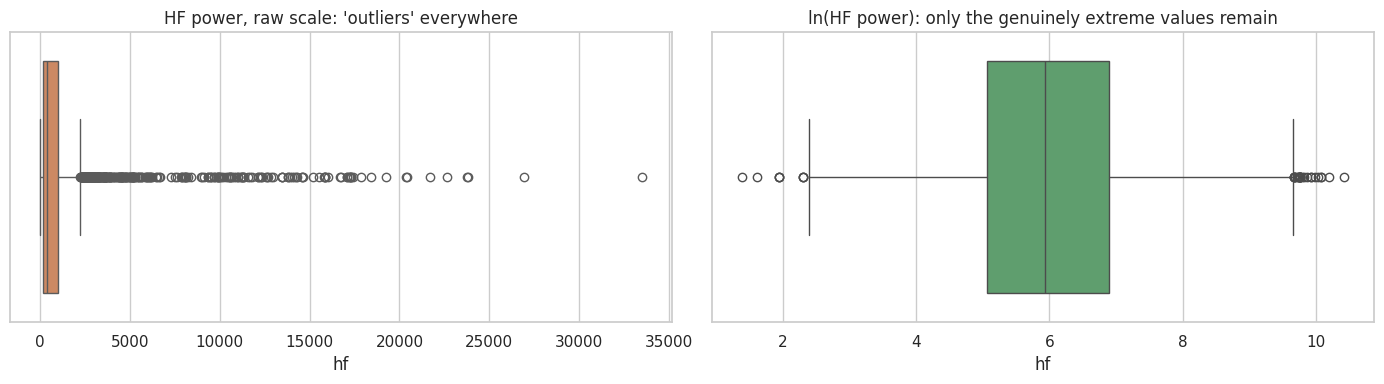

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.boxplot(x=H["hf"], ax=axes[0], color="#DD8452"); axes[0].set_title("HF power, raw scale: 'outliers' everywhere")
sns.boxplot(x=np.log(H["hf"]), ax=axes[1], color="#55A868"); axes[1].set_title("ln(HF power): only the genuinely extreme values remain")
plt.tight_layout(); plt.show()

for c in out_cols:
    lo, hi = H[c].quantile([.01, .99])
    H[f"{c}_w"] = H[c].clip(lo, hi)
log("hrv_measurements", "flag log-IQR & within-user outliers; add winsorized copies", H[[f"out_{c}" for c in out_cols]].any(axis=1).sum(),
    "extremes may be real illness signal → flag not delete")

**Result.** On the raw scale, IQR flags hundreds of spectral values, which is an artifact of skew. On the log scale only a small, defensible set remains. Those rows stay in the data with `out_*` flags, and the `_w` winsorized columns are available for models such as linear regression that are sensitive to leverage.

## 8. Data Transformation
| Transformation | Rationale |
|---|---|
| Parse all date strings to `datetime` and add `date` keys | enables joins across tables at the day level and time arithmetic |
| **Unit harmonization:** `mode`, `mxdmn` → ms; SpO₂ → %; sleep → hours | fixes the documentation mismatches from §3 so values read as expected and derived formulas work |
| **Natural log** of RMSSD, SDNN, LF, HF, VLF, total power, LF/HF | log-normal variables → near-normal, stabilizes variance, reduces leverage; ln(RMSSD) is the standard in HRV research |
| **Per-user z-score** of ln(RMSSD) and bpm | removes between-person baseline differences to isolate within-person change (§6.6) |
| **Ordinal encoding** of `age_range` → midpoint years | keeps order for correlation/regression while staying honest about the banding |
| **One-hot** `time_of_day`; **multi-hot** for selected tags | categorical → numeric for modeling; unambiguous tags only (§6.5) |
| **Pivot surveys** long → wide (user × date × scale) | one row per user-day for joining to measurements |

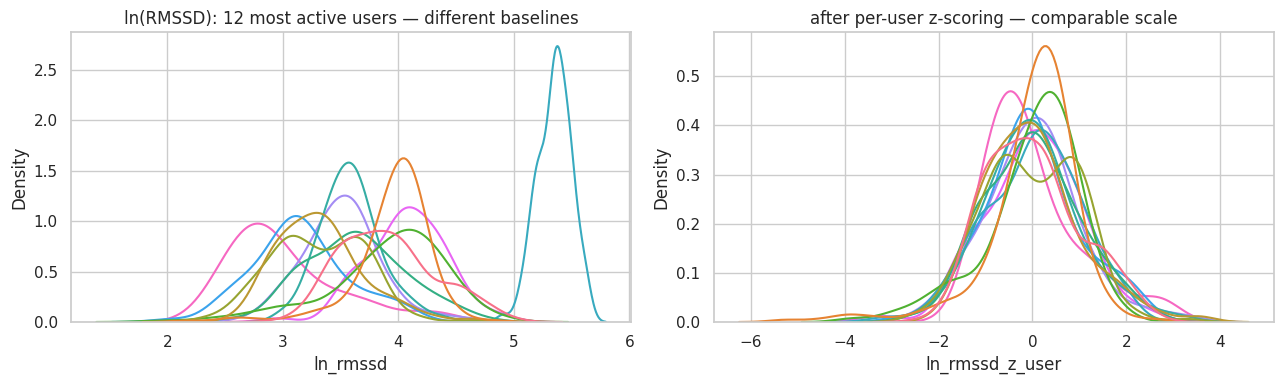

In [34]:
H["measurement_datetime"] = pd.to_datetime(H["measurement_datetime"])
H["date"] = H["measurement_datetime"].dt.normalize()
H["hour"] = H["measurement_datetime"].dt.hour
H["weekday"] = H["measurement_datetime"].dt.dayofweek

B["measurement_datetime"] = pd.to_datetime(B["measurement_datetime"].str.replace(r"\s+", " ", regex=True))
for t in ["wearables", "sleep", "weather"]:
    clean[t]["date"] = pd.to_datetime(clean[t]["day"])
clean["heart_rate"]["datetime"] = pd.to_datetime(clean["heart_rate"]["datetime"])
clean["surveys"]["date"] = pd.to_datetime(clean["surveys"]["created_at"])

# unit harmonization
H["mode_ms"] = H["mode"] * 1000
H["mxdmn_ms"] = H["mxdmn"] * 1000
W["average_spo2_pct"] = W["average_spo2_value"] * 100
S = clean["sleep"]
for c in dur_cols:
    S[c.replace("_duration", "_hours")] = S[c] / 3600
clean["weather"] = clean["weather"].rename(columns={"atmospheric_pressure": "atmospheric_pressure_hPa"})
log("multiple", "unit harmonization", 0, "fix documented-vs-actual unit mismatches")

# log transforms
for c in ["rmssd", "sdnn", "lf", "hf", "vlf", "total_power", "lfhf"]:
    H[f"ln_{c}"] = np.log(H[c])

# per-user standardization (only when the user has enough readings to define a baseline)
g = H.groupby("user_code")
n_user = g["rmssd"].transform("size")
for c in ["ln_rmssd", "bpm"]:
    z = (H[c] - g[c].transform("mean")) / g[c].transform("std")
    H[f"{c}_z_user"] = z.where(n_user >= 5)

# encodings
age_mid = {"18-24": 21, "25-34": 29.5, "35-44": 39.5, "45-54": 49.5, "55-64": 59.5, "65-74": 69.5}
P["age_mid"] = P["age_range"].map(age_mid)
H = pd.concat([H, pd.get_dummies(H["time_of_day"], prefix="tod", dtype=int)], axis=1)
TAGS = ["COVID-19", "Illness", "Tired", "Coffee", "Alcohol", "Headache", "Sleep", "Worry"]
tagsets = H["tags"].str.split(";").apply(lambda xs: {x.strip() for x in xs})
for t in TAGS:
    H[f"tag_{re.sub(r'[^a-z0-9]+', '_', t.lower()).strip('_')}"] = tagsets.apply(lambda s: int(t in s))
H["n_tags"] = tagsets.apply(lambda s: len(s - {""}))
clean["hrv_measurements"] = H

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.kdeplot(data=H, x="ln_rmssd", hue="user_code", legend=False, ax=axes[0],
            common_norm=False, hue_order=per_user.index[:12].tolist(), warn_singular=False)
axes[0].set_title("ln(RMSSD): 12 most active users — different baselines")
sns.kdeplot(data=H, x="ln_rmssd_z_user", hue="user_code", legend=False, ax=axes[1],
            common_norm=False, hue_order=per_user.index[:12].tolist(), warn_singular=False)
axes[1].set_title("after per-user z-scoring — comparable scale")
plt.tight_layout(); plt.show()

## 9. Feature Engineering
I created six features, each tied to a question the data can help answer.

| Feature | Definition | Why |
|---|---|---|
| `bmi` | weight / height² | standard cardiometabolic risk factor, known to affect HRV and COVID severity |
| `days_from_onset`, `covid_phase` | measurement date − symptom onset; binned to *pre-symptomatic* (<0), *acute* (0–13), *sub-acute* (14–27), *post-acute* (≥28) | turns calendar time into disease time, the axis on which HRV changes should appear. Bins follow common clinical framing (e.g., NICE's 4-week "ongoing symptomatic" threshold) and the stage-based approach of the *Frontiers in Big Data* study on this dataset |
| `rmssd_pct_vs_baseline` | % difference of RMSSD from the user's **pre-onset median** (fallback: overall median if < 3 pre-onset readings) | personal baselines matter more than population norms (§6.6). The pre-onset reference avoids contaminating the baseline with sick days |
| `stress_index` (Baevsky) | AMo / (2 · Mo · MxDMn), Mo & MxDMn in seconds | composite sympathetic-load index built from the dataset's otherwise under-used `amo`/`mode`/`mxdmn` columns; ln-transformed for skew |
| `artifact_pct`, `rec_duration_s`, `n_beats` | from raw `rr_data`: % of successive RR changes > 20% (Malik criterion); recording length; beat count | **signal-quality** features. Camera PPG can mis-detect beats, and high artifact share signals unreliable HRV. This is the closest thing to a device-quality proxy available |
| `symptom_burden` | mean of the nine `S_COVID_*` intensity scales for that user-day, rescaled 0 (none) – 1 (extremely severe) | a single daily severity target that can be related to physiology |

In [35]:
P["bmi"] = P["weight"] / (P["height"] / 100) ** 2

H = H.merge(P[["user_code", "symptoms_onset", "gender", "age_mid", "bmi"]], on="user_code", how="left")
H["days_from_onset"] = (H["date"] - H["symptoms_onset"]).dt.days
H["covid_phase"] = pd.cut(H["days_from_onset"], bins=[-np.inf, -1, 13, 27, np.inf],
                          labels=["pre-symptomatic", "acute (0-13d)", "sub-acute (14-27d)", "post-acute (28d+)"])

pre_med = H[H["days_from_onset"] < 0].groupby("user_code")["rmssd"].agg(["median", "size"])
all_med = H.groupby("user_code")["rmssd"].median()
baseline = pre_med["median"].where(pre_med["size"] >= 3).reindex(all_med.index).fillna(all_med)
H["baseline_source"] = np.where(H["user_code"].map(pre_med["size"]).fillna(0) >= 3, "pre-onset", "overall")
H["rmssd_pct_vs_baseline"] = (H["rmssd"] / H["user_code"].map(baseline) - 1) * 100

H["stress_index"] = H["amo"] / (2 * H["mode"] * H["mxdmn"])
H["ln_stress_index"] = np.log(H["stress_index"])

rr_arr = H["rr_data"].str.split(",").apply(lambda x: np.asarray(x, dtype=float))
H["n_beats"] = rr_arr.apply(len)
H["rec_duration_s"] = rr_arr.apply(lambda a: a.sum() / 1000)
H["artifact_pct"] = rr_arr.apply(lambda a: np.mean(np.abs(np.diff(a)) / a[:-1] > 0.20) * 100)

SV = clean["surveys"]
sym = SV[SV["scale"].str.match(r"S_COVID_(COUGH|FEVER|BREATH|FATIGUE|PAIN|TROUBLE|CONFUSION|BLUISH|OVERALL)$")]
burden = (sym.assign(v=(sym["value"] - 1) / 5).groupby(["user_code", "date"])["v"].mean()
          .rename("symptom_burden").reset_index())
H = H.merge(burden, on=["user_code", "date"], how="left")
clean["hrv_measurements"] = H

new_feats = ["bmi", "days_from_onset", "rmssd_pct_vs_baseline", "ln_stress_index", "artifact_pct", "rec_duration_s", "symptom_burden"]
H[new_feats].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
bmi,3245.0,27.74,7.46,16.29,22.31,26.81,31.25,54.28
days_from_onset,2685.0,9.75,46.83,-128.00,-9.00,20.00,40.00,97.00
rmssd_pct_vs_baseline,3245.0,8.78,49.54,-87.92,-21.54,0.00,24.67,616.67
ln_stress_index,3245.0,5.12,0.97,2.20,4.46,5.08,5.76,7.86
artifact_pct,3245.0,2.80,8.26,0.00,0.00,0.00,2.02,63.64
rec_duration_s,3245.0,91.27,37.15,47.77,74.47,83.74,94.29,344.32
symptom_burden,291.0,0.29,0.16,0.00,0.18,0.27,0.40,0.93


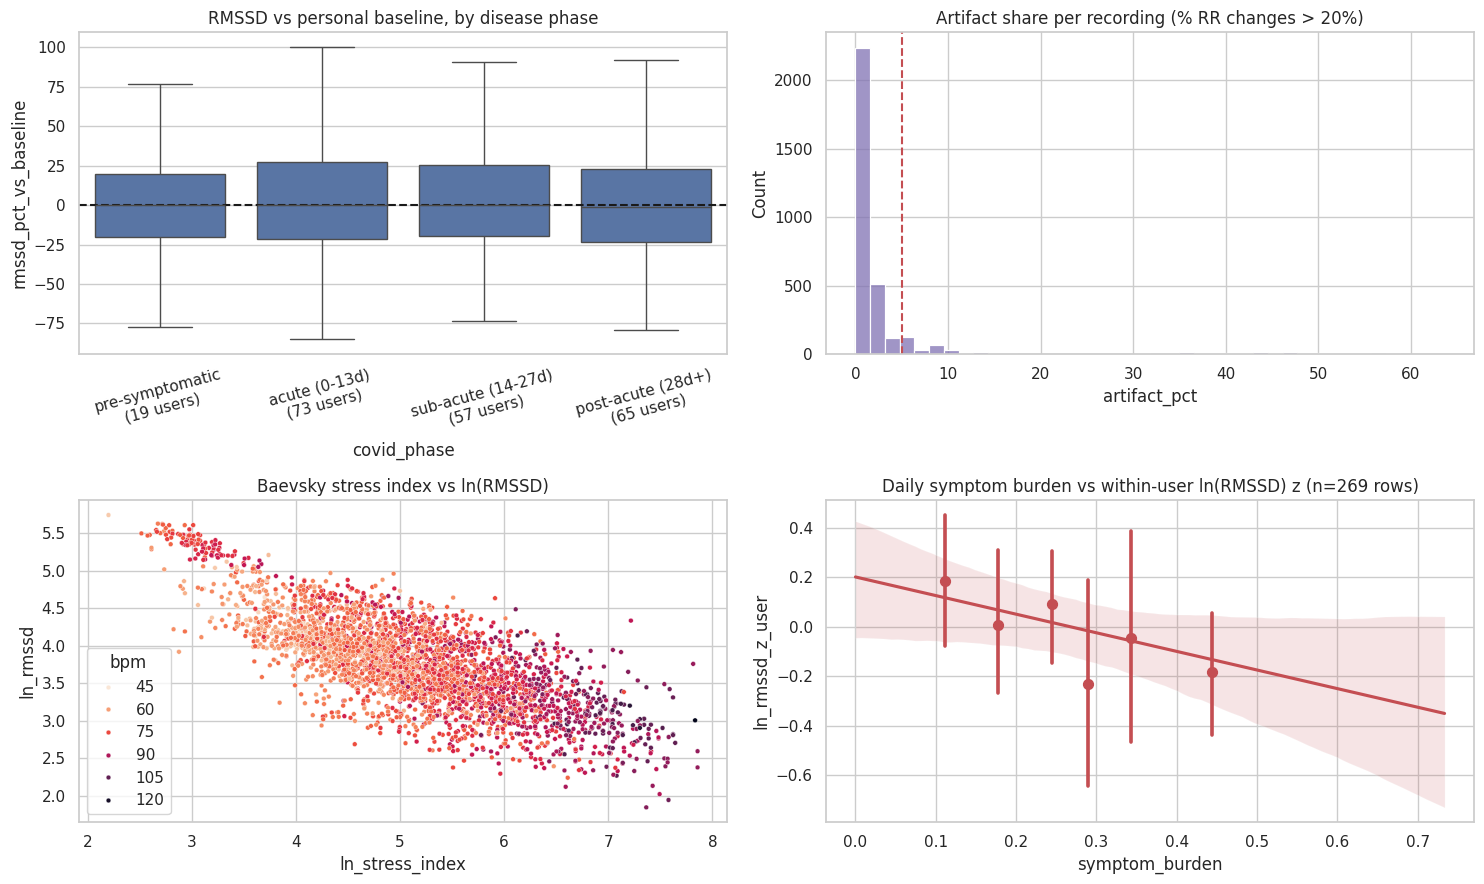

Recordings with artifact_pct > 5%: 11.7%
Spearman r(artifact_pct, ln_rmssd): 0.78
Spearman r(symptom_burden, within-user ln_rmssd z): -0.115
Baseline source: {'overall': 171, 'pre-onset': 14}
                    rows  users  median_pct_vs_baseline
covid_phase                                            
pre-symptomatic      714     19                     0.0
acute (0-13d)        371     73                     0.0
sub-acute (14-27d)   517     57                     0.0
post-acute (28d+)   1083     65                    -1.4


In [36]:
fig, axes = plt.subplots(2, 2, figsize=(15, 9))
ph = H.dropna(subset=["covid_phase"])
sns.boxplot(data=ph, x="covid_phase", y="rmssd_pct_vs_baseline", ax=axes[0, 0], showfliers=False)
axes[0, 0].axhline(0, c="k", ls="--"); axes[0, 0].set_title("RMSSD vs personal baseline, by disease phase")
axes[0, 0].tick_params(axis="x", rotation=15)
n_users = ph.groupby("covid_phase", observed=True)["user_code"].nunique()
axes[0, 0].set_xticklabels([f"{t.get_text()}\n({n_users.get(t.get_text(), 0)} users)" for t in axes[0, 0].get_xticklabels()])

sns.histplot(H["artifact_pct"], bins=40, ax=axes[0, 1], color="#8172B3")
axes[0, 1].set_title("Artifact share per recording (% RR changes > 20%)"); axes[0, 1].axvline(5, c="r", ls="--")

sns.scatterplot(data=H, x="ln_stress_index", y="ln_rmssd", hue="bpm", palette="rocket_r", s=12, ax=axes[1, 0])
axes[1, 0].set_title("Baevsky stress index vs ln(RMSSD)")

sb = H.dropna(subset=["symptom_burden"])
sns.regplot(data=sb, x="symptom_burden", y="ln_rmssd_z_user", x_bins=6, ax=axes[1, 1], color="#C44E52")
axes[1, 1].set_title(f"Daily symptom burden vs within-user ln(RMSSD) z (n={sb['ln_rmssd_z_user'].notna().sum()} rows)")
plt.tight_layout(); plt.show()

print(f"Recordings with artifact_pct > 5%: {(H['artifact_pct'] > 5).mean():.1%}")
print("Spearman r(artifact_pct, ln_rmssd):", round(H[["artifact_pct", "ln_rmssd"]].corr("spearman").iloc[0, 1], 3))
print("Spearman r(symptom_burden, within-user ln_rmssd z):", round(sb[["symptom_burden", "ln_rmssd_z_user"]].corr("spearman").iloc[0, 1], 3))
print("Baseline source:", H.drop_duplicates("user_code")["baseline_source"].value_counts().to_dict())
print(ph.groupby("covid_phase", observed=True).agg(rows=("rmssd", "size"), users=("user_code", "nunique"),
      median_pct_vs_baseline=("rmssd_pct_vs_baseline", "median")).round(1).to_string())

**Interpretation.**
- **Disease phase: no detectable effect, and that is itself informative.** Median % vs. baseline is about 0 in every phase. The design explains why. Only **14 of 185 users** have ≥ 3 pre-onset readings, so for most users the "baseline" is their *overall* median, which already includes sick days. That makes the comparison self-referential, and it is 0 by construction for users measured in a single phase. Detecting a COVID effect needs the small subset with genuine pre-onset data, plus artifact filtering (next bullet). This is a data-sufficiency limitation, not evidence of no effect.
- **Artifact share (the most important finding in this section).** It has a **strong positive** rank correlation with ln(RMSSD) (≈ 0.78), and about 12% of recordings exceed 5% artifacts. Mis-detected or ectopic beats create large successive differences, which *mechanically inflate* RMSSD. Many of the "high HRV" readings and many of the log-scale outliers from §7.4 are likely **measurement noise, not physiology**. `artifact_pct` should be used as a filter or covariate before drawing any conclusion.
- **Stress index.** It captures essentially the inverse of vagal HRV, as theory predicts. It is redundant with ln(RMSSD) for modeling but useful for interpretability.
- **Symptom burden.** Within-person HRV is slightly lower on days with higher symptom burden (Spearman ≈ −0.1). The direction is as expected but the effect is weak, and it rests on only about 9% of HRV rows that have a same-day survey. This is the relationship an early-warning model would try to exploit, and the data here is thin for it.

## 10. Integrated Analysis Table
One row per HRV measurement, enriched with same-day wearable, weather, and sleep context. All joins are **left joins**, so no measurements are lost; missing context stays NaN.

In [37]:
Wd = clean["wearables"][["user_code", "date", "resting_pulse", "steps_count", "active_calories_burned", "flag_partial_day"]]
Wx = clean["weather"][["user_code", "date", "avg_temperature_C", "humidity", "atmospheric_pressure_hPa"]]
Sd = clean["sleep"][["user_code", "date", "sleep_hours"]]
analytic = (H.merge(Wd, on=["user_code", "date"], how="left")
              .merge(Wx, on=["user_code", "date"], how="left")
              .merge(Sd, on=["user_code", "date"], how="left"))
assert len(analytic) == len(raw["hrv_measurements"]), "a join changed the row count!"

keep = ["user_code", "rr_code", "measurement_datetime", "date", "time_of_day", "hour", "gender", "age_mid", "bmi",
        "bpm", "meanrr", "sdnn", "rmssd", "pnn50", "lf", "hf", "vlf", "lfhf", "total_power", "mode_ms", "amo", "mxdmn_ms",
        "ln_rmssd", "ln_sdnn", "ln_lf", "ln_hf", "ln_lfhf", "ln_rmssd_z_user", "bpm_z_user", "rz_ln_rmssd_user",
        "how_feel", "how_mood", "how_sleep", "how_sleep_asked", "n_tags"] + \
       [c for c in analytic if c.startswith(("tag_", "tod_", "out_"))] + \
       ["days_from_onset", "covid_phase", "baseline_source", "rmssd_pct_vs_baseline", "stress_index", "ln_stress_index",
        "n_beats", "rec_duration_s", "artifact_pct", "symptom_burden",
        "resting_pulse", "steps_count", "active_calories_burned", "flag_partial_day",
        "avg_temperature_C", "humidity", "atmospheric_pressure_hPa", "sleep_hours"]
analytic = analytic[keep]
completeness = analytic[["ln_rmssd", "days_from_onset", "symptom_burden", "resting_pulse", "steps_count", "avg_temperature_C", "sleep_hours"]].notna().mean().mul(100).round(1)
print("Coverage of context in the integrated table (% of HRV rows):"); print(completeness.to_string())
print(analytic.shape)

Coverage of context in the integrated table (% of HRV rows):
ln_rmssd             100.0
days_from_onset       82.7
symptom_burden         9.0
resting_pulse         41.1
steps_count           34.1
avg_temperature_C     78.1
sleep_hours            4.2
(3245, 73)


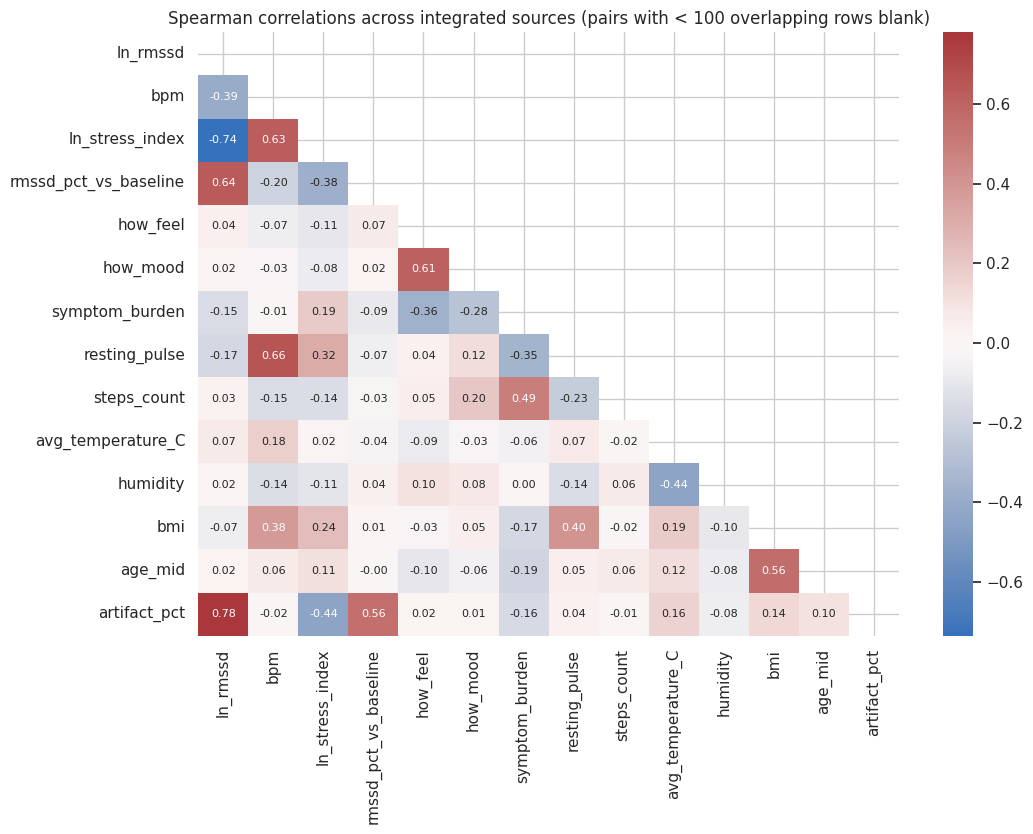

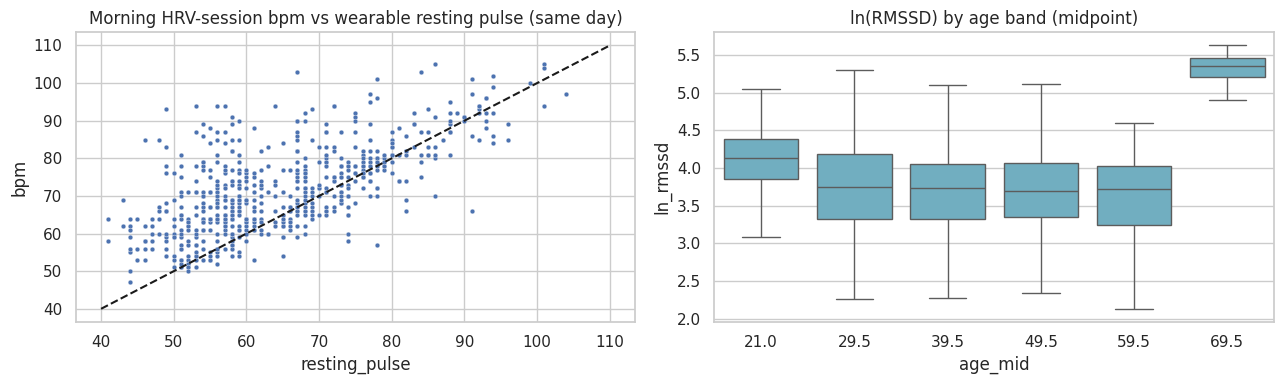

In [38]:
rel_cols = ["ln_rmssd", "bpm", "ln_stress_index", "rmssd_pct_vs_baseline", "how_feel", "how_mood", "symptom_burden",
            "resting_pulse", "steps_count", "avg_temperature_C", "humidity", "bmi", "age_mid", "artifact_pct"]
rc = analytic[rel_cols].corr(method="spearman", min_periods=100)
fig, ax = plt.subplots(figsize=(11, 8.5))
sns.heatmap(rc, mask=np.triu(np.ones_like(rc, dtype=bool)), annot=True, fmt=".2f", cmap="vlag", center=0, ax=ax, annot_kws={"size": 8})
ax.set_title("Spearman correlations across integrated sources (pairs with < 100 overlapping rows blank)")
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
d = analytic.dropna(subset=["resting_pulse"])
sns.scatterplot(data=d[d.time_of_day == "morning"], x="resting_pulse", y="bpm", s=12, ax=axes[0])
axes[0].plot([40, 110], [40, 110], "k--"); axes[0].set_title("Morning HRV-session bpm vs wearable resting pulse (same day)")
sns.boxplot(data=analytic, x="age_mid", y="ln_rmssd", ax=axes[1], showfliers=False, color="#64B5CD")
axes[1].set_title("ln(RMSSD) by age band (midpoint)")
plt.tight_layout(); plt.show()

**Interpretation.**
- **Cross-source validation.** Morning HRV-session heart rate tracks the wearable's resting pulse closely and sits slightly above it, as expected: a spot measurement vs. the day's minimum-ish resting value. This is independent evidence that the two sources are measuring the same physiology, a useful *accuracy* check across devices.
- **Age.** ln(RMSSD) declines with age, reproducing one of the best-established HRV findings. That the data recovers known physiology gives some confidence in its validity.
- **Weather.** Relationships with HRV are negligible here. Weather is better treated as a minor covariate than a driver.

## 11. Data Quality Assessment

In [39]:
scorecard = pd.DataFrame([
    ["Completeness", "hrv core metrics", f"{100 - raw['hrv_measurements'][hrv_num].isna().mean().mean() * 100:.0f}% filled", "Excellent"],
    ["Completeness", "wearables (all cols)", f"{100 - raw['wearables'].isna().mean().mean() * 100:.0f}% filled; 43% of users present", "Poor / structural"],
    ["Completeness", "symptoms_onset", f"{P['symptoms_onset'].notna().mean():.0%} valid", "Moderate"],
    ["Accuracy", "derived HRV vs rr_data", f"max |Δ RMSSD| = {checks.loc['rmssd', 'max_abs_diff']:.3f} ms", "Computationally exact"],
    ["Accuracy", "signal quality", f"{(H['artifact_pct'] > 5).mean():.0%} recordings > 5% artifacts", "Some noisy PPG"],
    ["Accuracy", "self-reported fields", f"{int(bad_onset.sum())} impossible onset dates, {int(bad_height.sum())} implausible heights", "Unverified"],
    ["Consistency", "documented vs actual units", f"{len(audit) - 2} mismatches", "Poor documentation"],
    ["Consistency", "cross-field identities", "calories, spectral sums, sleep duration all hold", "Good"],
    ["Consistency", "date formats", "3 formats (ISO, ISO+double space, M/D/YYYY)", "Inconsistent"],
    ["Integrity", "user_code referential integrity", "0 orphan rows", "Excellent"],
    ["Integrity", "natural-key uniqueness", f"{int(dup['duplicate_keys'].sum())} duplicate keys", "Needs dedup"],
    ["Integrity", "code book", "embedded-newline rows break parsing", "Flawed"],
    ["Validity", "physiological range rules", f"{int(validity['violations'].sum())} violations (incl. 99 short recordings kept)", "Handled / flagged"],
    ["Accuracy", "near-duplicate conflicts", f"{int(clean['heart_rate']['flag_hr_conflict'].sum())} HR timestamps differ > 20 bpm", "Flagged"],
], columns=["dimension", "check", "finding", "verdict"])
scorecard

,dimension,check,finding,verdict
0,Completeness,hrv core metrics,100% filled,Excellent
1,Completeness,wearables (all cols),52% filled; 43% of users present,Poor / structural
2,Completeness,symptoms_onset,72% valid,Moderate
3,Accuracy,derived HRV vs rr_data,max |Δ RMSSD| = 0.000 ms,Computationally exact
4,Accuracy,signal quality,12% recordings > 5% artifacts,Some noisy PPG
5,Accuracy,self-reported fields,"13 impossible onset dates, 3 implausible heights",Unverified
6,Consistency,documented vs actual units,7 mismatches,Poor documentation
7,Consistency,cross-field identities,"calories, spectral sums, sleep duration all hold",Good
8,Consistency,date formats,"3 formats (ISO, ISO+double space, M/D/YYYY)",Inconsistent
9,Integrity,user_code referential integrity,0 orphan rows,Excellent


### 11.1 Data profiling
Profiling was done systematically, table by table:
- shapes, types, key cardinality, and date ranges (§2);
- descriptive statistics with skew and coefficient of variation (§4);
- missingness rates and **patterns** (§5.1);
- key uniqueness (§5.2), rule-based validity (§5.3), and cross-field consistency (§5.4);
- distributions and correlations (§6).

The most important profiling insight is **structural**, not numeric. The dataset is a star-shaped collection of tables at different grains, with wildly different user coverage, so "the dataset" effectively means something different for each question.

### 11.2 Completeness
- **Core HRV table: complete.** Every measurement has all metrics and raw RR intervals.
- **Everything else is sparse, in a non-random way.** Wearable fields depend on device capability (MNAR). `how_sleep` is missing by questionnaire design. Sleep and BP cover only 10 and 28 users.
- **Completeness is also a sampling problem.** 38 users never reported an onset date, 3 more reported impossible ones, and many users measured only once, so *longitudinal* completeness is much worse than cell-level completeness suggests.
- **Silent incompleteness.** Partial-day wearable syncs look like valid numbers (e.g., total kcal < 1000), which is why they got a flag.

### 11.3 Accuracy
- **Computational accuracy is verified.** HRV metrics recompute exactly from `rr_data`.
- **Measurement accuracy is uncertain.**
  - The capture device (camera PPG vs. chest strap) isn't recorded, and PPG is known to be noisier.
  - The artifact-share feature shows a meaningful minority of noisy recordings, and artifacts inflate RMSSD.
  - On the other hand, cross-device agreement (session bpm vs. wearable resting pulse) and recovery of known physiology (age → lower HRV; morning → higher HRV) are encouraging.
- **Label accuracy is the weakest link.**
  - COVID status and onset dates are self-reported and unverified.
  - 7% of onset dates are impossible (mostly birth dates in the wrong field), and two participants report ~250 cm heights.
  - Multi-source heart-rate conflicts reach 100+ bpm.
  - The self-report scale for `how_*` is undocumented.

### 11.4 Consistency
- **Within a record**, the data is consistent: bpm ≈ 60000/meanrr, total power = LF+HF+VLF, total kcal = basal + active, sleep duration = end − begin.
- **Between the documentation and the data**, it is not:
  - several fields are in different units than documented (`mode`, SpO₂, sleep duration, pressure);
  - a column name differs (`daytime` vs. `datetime`);
  - date formats vary (MM/DD/YYYY vs. ISO, plus a double-spaced timestamp);
  - active calories use "missing" to mean zero.
- **Semantic consistency of `tags`** is weak: modifier-only tags ("After", "A lot") and apparent "select-all" rows.
- **Time zone** is never specified. The sleep table shows the *same night* stored under different offsets, so day-level alignment across tables carries a ±1 day risk near midnight.

### 11.5 Integrity
- **Referential integrity is strong.** Every `user_code` in every table exists in `participants`, and IDs follow one format.
- **Entity integrity is weaker.** Natural keys are duplicated in `heart_rate` (conflicting multi-source readings), `sleep` (time-zone copies of the same night), and `surveys`.
- **The code book (`scales_description.csv`) is structurally corrupted** by unescaped newlines, so a few scale descriptions can't be looked up reliably.
- **There are no foreign keys between measurement tables** (e.g., a BP reading doesn't reference the HRV session it came from). Relationships must be inferred by date, which loses precision.

### 11.6 Data lineage & provenance
**Upstream (provenance).**
```
User device (phone camera PPG | BLE strap | Apple Watch/Garmin)
   → Apple Health / Google Fit sync (wearables, heart_rate, sleep)
   → Welltory app: beat detection → RR intervals → HRV metrics (proprietary pipeline,
     described in Welltory's IEEE 2019 & MDPI Sensors 2021 papers)
   → in-app surveys & tags (self-report)
   → weather API lookup by user city (source/provider not documented)
   → Welltory export: anonymization, daily aggregation, CSV (2020; repo last updated later)
   → GitHub: Welltory/hrv-covid19 (CC licence)
```
**Gaps in provenance.**
- no device/method column;
- no app or algorithm version;
- no time zone (and the sleep table proves offsets changed: the same night appears under two UTC offsets);
- no weather provider;
- no description of the aggregation rules for daily wearables;
- the anonymization method is unstated;
- the repo has limited version history for the data files, so the exact snapshot used in published papers can't be pinned.

I recorded the source URL and the load path at the top of the notebook. Pinning a git commit SHA is recommended for full reproducibility.

**Downstream (my lineage).**
- Raw tables are loaded once into `raw` and **never modified**.
- All changes happen in `clean`, and each step is written to `cleaning_log` (below) with rows affected and rationale.
- Flags (`flag_*`, `out_*`, `*_imputed`, `has_*`, `baseline_source`) preserve *what* was changed at the row level, so any analysis can include or exclude the affected records.

In [40]:
pd.DataFrame(cleaning_log)

,table,step,rows_affected,rationale
0,heart_rate,"collapse duplicate (user, datetime) to mean; f...",7330,two sources at one timestamp; 1174 large confl...
1,sleep,"keep one row per (user, day); flag tz_duplicate",38,same night stored under different UTC offsets ...
2,surveys,"keep max value per (user, scale, date)",24,conservative severity; no intra-day timestamp
3,participants,invalid onset date → NaT,13,outside study window: 10 birth-date-like (1967...
4,participants,height outside 140–220 cm → NaN,3,≈250 cm ×2 (both also have invalid onset) + 13...
5,heart_rate,drop HR < 30 or > 220,110,outside survivable/awake adult range → sensor ...
6,wearables,pulse_min < 30 → NaN,6,sensor dropout artifact
7,wearables,flag total kcal < 1000 as partial-day sync,1,basal alone exceeds this for adults; indicates...
8,blood_pressure,implausible BP → NaN,1,diastolic < 40 mmHg is incompatible with a con...
9,wearables,recover active kcal = total − basal,1898,source encodes 0 as missing


In [41]:
out_dir = Path("processed"); out_dir.mkdir(exist_ok=True)
analytic.to_csv(out_dir / "hrv_analytic_table.csv", index=False)
P.to_csv(out_dir / "participants_clean.csv", index=False)
pd.DataFrame(cleaning_log).to_csv(out_dir / "cleaning_log.csv", index=False)
print("Saved:", *sorted(p_.name for p_ in out_dir.iterdir()))

Saved: cleaning_log.csv hrv_analytic_table.csv participants_clean.csv


## 12. Summary, Key Decisions & Next Steps
### What I found
- A multi-table, multi-grain, **self-reported** COVID/wearables dataset. The HRV table is complete and computationally exact; the context tables are sparse in structurally meaningful ways.
- Documentation errors on units and formats, impossible self-reported values, near-duplicate multi-source records, and a corrupted code book.
- Strong physiological sanity checks pass: circadian pattern, age effect, and cross-device heart-rate agreement.
- Weak but directionally expected within-person relationships (lower HRV on high-symptom days).
- A strong artifact → RMSSD relationship, which means signal quality must be controlled before any physiological conclusion.

### Key decisions & rationale
1. **Flag before fixing, fix before deleting.** In illness data, extremes are often signal.
2. **Handle missingness by mechanism.** Structural gaps are left as-is, encoded zeros are recovered, and there is minimal, flagged imputation only where a downstream feature (BMI) needs it.
3. **Log scale for HRV power metrics**, for both outlier detection and modeling.
4. **Personal baselines over population norms**, because between-person variance dwarfs within-person change.
5. **Resolve duplicates by what they actually are.** The investigation showed sleep "naps" were time-zone copies, so the right fix was *keep one*, not *sum*. Heart-rate conflicts are averaged and flagged; survey repeats keep the max.
6. **Keep raw data immutable** and log every transformation for lineage.

### Limitations
- Small effective sample for longitudinal analysis (few users with pre-onset and post-onset data).
- Unverified labels; device type unknown; time zone unknown.
- Results are exploratory and not causal.

### Next steps
- Filter or weight by `artifact_pct` and `rec_duration_s`, then re-examine phase effects and the outlier set.
- Use mixed-effects models (random intercept per user) to test the phase → ln(RMSSD) relationship, controlling for time of day.
- Use the minute-level `heart_rate` table to build nightly resting-HR trends, a candidate early-warning feature.
- Split train/test **by user** for any predictive model.